[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Advanced-Time-Series/blob/main/notebooks/EN/chapter6_lecture_notebook.ipynb)

# Advanced Time Series Analysis and Forecasting — Chapter 6: State space models and Bayesian filtering

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- The general linear Gaussian model: Kalman filter and smoother with exact diffuse initialisation, in numpy.
- The exact likelihood, its maximisation, and the pile-up problem.
- Simulation smoothers (Carter–Kohn, Durbin–Koopman, precision sampler) and Gibbs sampling.
- Stochastic volatility: the KSC mixture, Gibbs, the bootstrap particle filter, PMMH.
- Nonlinear filters: unscented transform, bootstrap and auxiliary particle filters.
- TVP regression, a dynamic factor model at the ragged edge, trend–cycle decompositions, UC-SV trend inflation.
- Numbers of draws, particles and replications are reduced here to keep the run short.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/ATS/Chapter_6'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/ATS - Modelarea avansata a seriilor de timp/repo/notebooks/EN


In [2]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [3]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import ats_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the ATS repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [4]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Advanced-Time-Series/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the ATS repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Definitions used in the whole notebook

- State space engine: `ssm`, `kalman_filter` (exact diffuse), `kalman_smoother`, `big_kappa`.
- Samplers: `simulate_ssm`, `sim_smoother_dk`, `ffbs`, `precision_rw`, `ineff`.
- Stochastic volatility: `draw_s_ksc`, `draw_h_ksc`, `sv_gibbs`, `garch11`, `pf_sv`.
- Trend–cycle: `uc_model`, `fit_uc`, `bn_arma`, `hamilton_filter`, `smooth_trend_model`.

In [5]:
import time
from scipy import linalg
SEED = 2026
LOG2PI = np.log(2 * np.pi)
KSC_P = np.array([0.0073, 0.10556, 2e-05, 0.04395, 0.34001, 0.24566, 0.2575])
KSC_M = np.array([-10.12999, -3.97281, -8.56686, 2.77786, 0.61942, 1.79518, -1.08819])
KSC_V = np.array([5.79596, 2.61369, 5.1795, 0.16735, 0.64009, 0.34023, 1.26261])
SV = {'start': '2016-01-01', 'end': '2026-09-18', 'offset': 0.001}
MNZ = {'start': '1947-01-01', 'end': '1998-04-01'}
UCSV = {'gamma': 0.2, 'start_us': '1953-01-01', 'start_ro': '2001-01-01'}
TVP = {'start': '2005-08-01'}
DFM_SERIES = {'INDPRO': 'industrial production', 'PAYEMS': 'payroll employment', 'W875RX1': 'real personal income less transfers', 'CMRMTSPL': 'real manufacturing and trade sales'}
_sv_cache = {}


def save(name, save_it=True):
    st.check_no_grey(plt.gcf())
    if save_it:
        st.save_fig(name)
    else:
        plt.show()
        plt.close()


def ssm(Z, T, R, Q, H, a1=None, P1=None, Pinf=None, c=None):
    """A time-invariant state space model (Durbin and Koopman 2012 notation), univariate observation:
        y_t = Z_t alpha_t + eps_t,          eps_t ~ N(0, H)
        alpha_{t+1} = c + T alpha_t + R eta_t,   eta_t ~ N(0, Q)
        alpha_1 ~ N(a1, P1 + kappa * Pinf), kappa -> infinity (exact diffuse part Pinf).
    Z may be a vector (m,) or a matrix (n, m) of time-varying rows (regressions)."""
    T = np.atleast_2d(np.asarray(T, float))
    m = T.shape[0]
    R = np.atleast_2d(np.asarray(R, float)).reshape(m, -1)
    Q = np.atleast_2d(np.asarray(Q, float))
    return dict(Z=np.asarray(Z, float), T=T, R=R, Q=Q, RQR=R @ Q @ R.T, H=float(H),
                a1=np.zeros(m) if a1 is None else np.asarray(a1, float),
                P1=np.zeros((m, m)) if P1 is None else np.atleast_2d(np.asarray(P1, float)),
                Pinf=np.zeros((m, m)) if Pinf is None else np.atleast_2d(np.asarray(Pinf, float)),
                c=np.zeros(m) if c is None else np.asarray(c, float))


def _zrow(mod, t):
    Z = mod['Z']
    return Z[t] if Z.ndim == 2 else Z


def kalman_filter(y, mod, tol=1e-8):
    """Kalman filter with exact diffuse initialisation (Koopman 1997; Durbin and Koopman 2012, Section 5.2) for a
    univariate observation. Missing values (NaN) skip the update. Returns predicted states a_t, P_t (P_*), the
    diffuse parts, innovations v_t, variances F_t and the diffuse log-likelihood (Durbin and Koopman 2012, eq. 7.4)."""
    y = np.asarray(y, float)
    n, m = len(y), mod['T'].shape[0]
    T, RQR, H, c = mod['T'], mod['RQR'], mod['H'], mod['c']
    a, P, Pi = mod['a1'].copy(), mod['P1'].copy(), mod['Pinf'].copy()
    out = dict(a=np.zeros((n, m)), P=np.zeros((n, m, m)), Pinf=np.zeros((n, m, m)), v=np.full(n, np.nan), att=np.zeros((n, m)),
               F=np.full(n, np.nan), Finf=np.zeros(n), K0=np.zeros((n, m)), K1=np.zeros((n, m)),
               ll=np.zeros(n), diffuse=np.zeros(n, bool))
    d = 0
    for t in range(n):
        Z = _zrow(mod, t)
        out['a'][t], out['P'][t], out['Pinf'][t] = a, P, Pi
        is_diff = np.abs(Pi).max() > tol
        out['diffuse'][t] = is_diff
        if np.isnan(y[t]):                       # missing observation: prediction only
            out['att'][t] = a
            a, P, Pi = c + T @ a, T @ P @ T.T + RQR, T @ Pi @ T.T
            continue
        v = y[t] - Z @ a
        Ms, Fs = P @ Z, Z @ P @ Z + H
        out['v'][t] = v
        if is_diff:
            Mi = Pi @ Z
            Fi = Z @ Mi
            out['Finf'][t] = Fi
            if Fi > tol:
                out['att'][t] = a + Mi * v / Fi
                F1, F2 = 1 / Fi, -Fs / Fi ** 2
                K0, K1 = T @ Mi * F1, T @ (Ms * F1 + Mi * F2)
                L0, L1 = T - np.outer(K0, Z), -np.outer(K1, Z)
                a = c + T @ a + K0 * v
                Pi, P = T @ Pi @ L0.T, T @ Pi @ L1.T + T @ P @ L0.T + RQR
                out['F'][t], out['K0'][t], out['K1'][t] = Fi, K0, K1
                out['ll'][t] = -0.5 * (LOG2PI + np.log(Fi))
            else:
                out['att'][t] = a + Ms * v / Fs
                K0 = T @ Ms / Fs
                L0 = T - np.outer(K0, Z)
                a = c + T @ a + K0 * v
                Pi, P = T @ Pi @ T.T, T @ P @ L0.T + RQR
                out['F'][t], out['K0'][t] = Fs, K0
                out['ll'][t] = -0.5 * (LOG2PI + np.log(Fs) + v ** 2 / Fs)
            d = t + 1
        else:
            out['att'][t] = a + Ms * v / Fs
            K = T @ Ms / Fs
            a = c + T @ a + K * v
            P = T @ P @ (T - np.outer(K, Z)).T + RQR
            out['F'][t], out['K0'][t] = Fs, K
            out['ll'][t] = -0.5 * (LOG2PI + np.log(Fs) + v ** 2 / Fs)
        P = 0.5 * (P + P.T)
    out['d'], out['loglik'] = d, float(out['ll'].sum())
    out['a_next'], out['P_next'] = a, P
    return out


def kalman_smoother(y, mod, kf=None, tol=1e-8):
    """State smoother with exact diffuse initialisation (Durbin and Koopman 2012, Section 5.3): backward recursions
    for r_t, N_t (and r^(1), N^(1), N^(2) in the diffuse period). Returns smoothed states and their variances."""
    y = np.asarray(y, float)
    kf = kf or kalman_filter(y, mod, tol)
    n, m = len(y), mod['T'].shape[0]
    T, H = mod['T'], mod['H']
    r0, r1 = np.zeros(m), np.zeros(m)
    N0, N1, N2 = np.zeros((m, m)), np.zeros((m, m)), np.zeros((m, m))
    ah, V = np.zeros((n, m)), np.zeros((n, m, m))
    for t in range(n - 1, -1, -1):
        Z = _zrow(mod, t)
        a, P, Pi, v = kf['a'][t], kf['P'][t], kf['Pinf'][t], kf['v'][t]
        if np.isnan(y[t]):
            r0, N0 = T.T @ r0, T.T @ N0 @ T
            if kf['diffuse'][t]:
                r1, N1, N2 = T.T @ r1, T.T @ N1 @ T, T.T @ N2 @ T
        elif not kf['diffuse'][t]:
            F = kf['F'][t]
            L = T - np.outer(kf['K0'][t], Z)
            r0 = Z * v / F + L.T @ r0
            N0 = np.outer(Z, Z) / F + L.T @ N0 @ L
        else:
            Fi = kf['Finf'][t]
            if Fi > tol:
                Fs = Z @ P @ Z + H
                F1, F2 = 1 / Fi, -Fs / Fi ** 2
                L0, L1 = T - np.outer(kf['K0'][t], Z), -np.outer(kf['K1'][t], Z)
                r1n = Z * v * F1 + L0.T @ r1 + L1.T @ r0
                r0n = L0.T @ r0
                N2n = (np.outer(Z, Z) * F2 + L0.T @ N2 @ L0 + L0.T @ N1 @ L1 + L1.T @ N1 @ L0
                       + L1.T @ N0 @ L1)
                N1n = np.outer(Z, Z) * F1 + L0.T @ N1 @ L0 + L1.T @ N0 @ L0 + L0.T @ N0 @ L1
                N0n = L0.T @ N0 @ L0
                r0, r1, N0, N1, N2 = r0n, r1n, N0n, N1n, N2n
            else:
                Fs = kf['F'][t]
                L0 = T - np.outer(kf['K0'][t], Z)
                r0 = Z * v / Fs + L0.T @ r0
                N0 = np.outer(Z, Z) / Fs + L0.T @ N0 @ L0
                r1, N1, N2 = T.T @ r1, T.T @ N1 @ L0, T.T @ N2 @ T
        if kf['diffuse'][t]:
            ah[t] = a + P @ r0 + Pi @ r1
            V[t] = P - P @ N0 @ P - (Pi @ N1 @ P).T - Pi @ N1 @ P - Pi @ N2 @ Pi
        else:
            ah[t] = a + P @ r0
            V[t] = P - P @ N0 @ P
    return dict(alpha=ah, V=V, kf=kf)


def big_kappa(mod, kappa):
    """The same model with the diffuse part replaced by kappa * Pinf (the approximate diffuse initialisation)."""
    m2 = dict(mod)
    m2['P1'] = mod['P1'] + kappa * mod['Pinf']
    m2['Pinf'] = np.zeros_like(mod['Pinf'])
    return m2


def local_level(s2eps, s2eta):
    """Local level model: y_t = mu_t + eps_t, mu_{t+1} = mu_t + eta_t, mu_1 diffuse."""
    return ssm([1.0], [[1.0]], [[1.0]], [[s2eta]], s2eps, Pinf=[[1.0]])


def num_hessian(f, x, h=1e-4):
    x = np.asarray(x, float)
    k = len(x)
    Hm = np.zeros((k, k))
    for i in range(k):
        for j in range(i, k):
            e1, e2 = np.zeros(k), np.zeros(k)
            e1[i], e2[j] = h, h
            Hm[i, j] = Hm[j, i] = (f(x + e1 + e2) - f(x + e1 - e2) - f(x - e1 + e2) + f(x - e1 - e2)) / (4 * h * h)
    return Hm


def fit_local_level(y):
    """Exact diffuse ML of the local level model with numpy: log-variances, BFGS from a grid start."""
    y = np.asarray(y, float)
    f = lambda th: -kalman_filter(y, local_level(np.exp(th[0]), np.exp(th[1])))['loglik']   # noqa: E731
    v = np.nanvar(np.diff(y))
    starts = [np.log([v * a, v * (1 - a) + 1e-6]) for a in (0.2, 0.5, 0.8)]
    best = min((optimize.minimize(f, s, method='BFGS') for s in starts), key=lambda r: r.fun)
    th = best.x
    Hn = num_hessian(f, th)
    se = np.sqrt(np.diag(np.linalg.inv(Hn)))
    return dict(s2eps=float(np.exp(th[0])), s2eta=float(np.exp(th[1])), loglik=float(-best.fun), se_log=se.tolist(),
                q=float(np.exp(th[1] - th[0])))


def us_inflation(start='1953-01-01', end=None):
    """US quarterly inflation, GDP price deflator (FRED GDPDEF), 400 x log difference (% a.r.)."""
    p = read_fred('GDPDEF')
    pi = 400 * np.log(p).diff().dropna()
    return pi.loc[start:end].rename('pi_us')


def hicp_index(geo):
    """Monthly HICP, all items, index 2025 = 100 (Eurostat prc_hicp_minr)."""
    return read_eurostat('prc_hicp_minr', f'M.I25.TOTAL.{geo}')


def hicp_yoy(geo):
    """12-month HICP inflation, % (Eurostat prc_hicp_minr, annual rate of change)."""
    return read_eurostat('prc_hicp_minr', f'M.RCH_A.TOTAL.{geo}')


def ro_quarterly_inflation(start=UCSV['start_ro']):
    """Romanian quarterly HICP inflation: quarterly averages of the monthly index, 400 x log difference (% a.r.),
    complete quarters only."""
    p = hicp_index('RO')
    q = p.resample('QS').mean()
    cnt = p.resample('QS').count()
    q = q[cnt == 3]
    return (400 * np.log(q).diff()).dropna().loc[start:].rename('pi_ro')


def gdp_log(geo='RO', start='1995-01-01'):
    """100 x log real GDP, quarterly, seasonally and calendar adjusted, chain-linked volumes 2010 (Eurostat
    namq_10_gdp); for 'US' the FRED series GDPC1."""
    if geo == 'US':
        s = read_fred('GDPC1')
    else:
        s = read_eurostat('namq_10_gdp', f'Q.CLV10_MEUR.SCA.B1GQ.{geo}')
    return (100 * np.log(s)).loc[start:].rename(f'y_{geo}')


def returns(name, start=SV['start'], end=SV['end']):
    """Daily log returns in % (course data, EODHD), demeaned."""
    r = 100 * np.log(load_close(name)).diff().dropna().loc[start:end]
    return r - r.mean()


def simulate_ssm(mod, n, rng, mask=None):
    """Draw (alpha+, y+) from the model; the diffuse part of the initial state is set to a1 (DK 2002, mean correction
    makes the draw invariant to it). mask: NaN pattern of the data (missing values stay missing)."""
    m = mod['T'].shape[0]
    L1 = np.linalg.cholesky(mod['P1'] + 1e-12 * np.eye(m))
    Lq = np.linalg.cholesky(mod['Q'] + 1e-14 * np.eye(mod['Q'].shape[0]))
    al = np.zeros((n, m))
    yp = np.zeros(n)
    a = mod['a1'] + L1 @ rng.standard_normal(m)
    for t in range(n):
        al[t] = a
        yp[t] = _zrow(mod, t) @ a + np.sqrt(mod['H']) * rng.standard_normal()
        a = mod['c'] + mod['T'] @ a + mod['R'] @ (Lq @ rng.standard_normal(Lq.shape[0]))
    if mask is not None:
        yp[mask] = np.nan
    return al, yp


def sim_smoother_dk(y, mod, rng):
    """Durbin and Koopman (2002) simulation smoother, mean-correction form: alpha~ = alpha+ + E[alpha | y - y+] computed
    by one Kalman smoother pass on y - y+ in the model with zero intercepts and zero initial mean."""
    y = np.asarray(y, float)
    al, yp = simulate_ssm(mod, len(y), rng, mask=np.isnan(y))
    m0 = dict(mod)
    m0['a1'], m0['c'] = np.zeros_like(mod['a1']), np.zeros_like(mod['c'])
    return al + kalman_smoother(y - yp, m0)['alpha']


def ffbs(y, mod, rng):
    """Carter and Kohn (1994) / Fruhwirth-Schnatter (1994): forward filtering, backward sampling (proper prior,
    no diffuse part). alpha_n ~ N(a_{n|n}, P_{n|n}); alpha_t | alpha_{t+1}, y_{1:t} ~ N(m_t, S_t)."""
    y = np.asarray(y, float)
    n, m = len(y), mod['T'].shape[0]
    T, RQR, c, H = mod['T'], mod['RQR'], mod['c'], mod['H']
    af, Pf = np.zeros((n, m)), np.zeros((n, m, m))
    a, P = mod['a1'].copy(), mod['P1'].copy()
    for t in range(n):
        Z = _zrow(mod, t)
        if not np.isnan(y[t]):
            F = Z @ P @ Z + H
            k = P @ Z / F
            a = a + k * (y[t] - Z @ a)
            P = P - np.outer(k, Z @ P)
        af[t], Pf[t] = a, P
        a, P = c + T @ a, T @ P @ T.T + RQR
    out = np.zeros((n, m))
    out[-1] = rng.multivariate_normal(af[-1], 0.5 * (Pf[-1] + Pf[-1].T))
    for t in range(n - 2, -1, -1):
        Pp = T @ Pf[t] @ T.T + RQR
        G = Pf[t] @ T.T @ np.linalg.pinv(Pp)
        mu = af[t] + G @ (out[t + 1] - c - T @ af[t])
        S = Pf[t] - G @ T @ Pf[t]
        out[t] = mu + np.linalg.cholesky(0.5 * (S + S.T) + 1e-12 * np.eye(m)) @ rng.standard_normal(m)
    return out


def precision_rw(y, s2eps, s2eta, m0=0.0, v0=1e6, rng=None, draw=True):
    """Precision sampler (Chan and Jeliazkov 2009) for y_t = mu_t + eps_t, mu_t = mu_{t-1} + eta_t, mu_1 ~ N(m0, v0):
    the posterior precision of mu is tridiagonal, so one banded Cholesky factorisation gives the mean and a draw in
    O(n). s2eps and s2eta may be vectors (time-varying variances)."""
    y = np.asarray(y, float)
    n = len(y)
    se = np.broadcast_to(np.asarray(s2eps, float), (n,))
    sh = np.broadcast_to(np.asarray(s2eta, float), (n,)).copy()
    w = 1 / sh                                    # w[t] = 1 / var(mu_t - mu_{t-1}) for t >= 1 (w[0] unused)
    diag = 1 / se + np.r_[1 / v0, np.zeros(n - 1)] + np.r_[w[1:], 0] + np.r_[0, w[1:]]
    off = -w[1:]
    ab = np.zeros((2, n))
    ab[0, 1:], ab[1] = off, diag                 # upper banded form for cholesky_banded
    U = linalg.cholesky_banded(ab, lower=False)
    b = y / se + np.r_[m0 / v0, np.zeros(n - 1)]
    mean = linalg.cho_solve_banded((U, False), b)
    if not draw:
        return mean
    rng = rng or np.random.default_rng()
    return mean + linalg.solve_banded((0, 1), U, rng.standard_normal(n))


def ineff(x, L=None):
    """Inefficiency factor 1 + 2 sum_k rho_k with Parzen weights (bandwidth L), as in Kim, Shephard and Chib (1998)."""
    x = np.asarray(x, float) - np.mean(x)
    n = len(x)
    L = L or int(min(n // 4, 500))
    ac = np.correlate(x, x, 'full')[n - 1:n + L] / (x @ x)
    k = np.arange(1, L + 1) / L
    w = np.where(k <= 0.5, 1 - 6 * k ** 2 + 6 * k ** 3, 2 * (1 - k) ** 3)
    return float(1 + 2 * (w * ac[1:L + 1]).sum())


def ar1_precision(n, phi, s2):
    """Tridiagonal precision of a stationary AR(1) h_t - mu = phi (h_{t-1} - mu) + eta_t, var(eta) = s2
    (upper banded storage: row 0 superdiagonal, row 1 diagonal)."""
    d = np.full(n, (1 + phi ** 2) / s2)
    d[0] = d[-1] = 1 / s2
    ab = np.zeros((2, n))
    ab[0, 1:] = -phi / s2
    ab[1] = d
    return ab


def draw_h_ksc(ystar, s, mu, phi, s2, rng):
    """h | indicators, theta: y*_t - (m_s - 1.2704) = h_t + e_t, e_t ~ N(0, v_s); AR(1) prior; precision sampler."""
    n = len(ystar)
    ab = ar1_precision(n, phi, s2)
    ab[1] += 1 / KSC_V[s]
    prior_b = np.full(n, (1 - phi) ** 2 * mu / s2)
    prior_b[0] = prior_b[-1] = (1 - phi) * mu / s2
    b = prior_b + (ystar - (KSC_M[s] - 1.2704)) / KSC_V[s]
    U = linalg.cholesky_banded(ab, lower=False)
    mean = linalg.cho_solve_banded((U, False), b)
    return mean + linalg.solve_banded((0, 1), U, rng.standard_normal(n))


def draw_s_ksc(ystar, h, rng):
    """Mixture indicators: P(s_t = i) proportional to p_i N(y*_t - h_t; m_i - 1.2704, v_i)."""
    e = (ystar - h)[:, None] - (KSC_M - 1.2704)[None, :]
    lw = np.log(KSC_P)[None, :] - 0.5 * np.log(KSC_V)[None, :] - 0.5 * e ** 2 / KSC_V[None, :]
    w = np.exp(lw - lw.max(1, keepdims=True))
    cw = np.cumsum(w / w.sum(1, keepdims=True), axis=1)
    return (rng.random(len(h))[:, None] > cw).sum(1).clip(0, 6)


def sv_gibbs(y, draws=6000, burn=1000, offset=SV['offset'], rng=None, keep_h=True):
    """Kim, Shephard and Chib (1998) Gibbs sampler for y_t = exp(h_t/2) eps_t, h_t = mu + phi(h_{t-1} - mu) + s eta_t.
    y* = log(y^2 + c var(y)), c = 0.001. Priors as in KSC: (phi + 1)/2 ~ Beta(20, 1.5), s^2 ~ IG(2.5, 0.025),
    mu ~ N(0, 10). Blocks: indicators;
    h by the precision sampler; s^2 (inverse gamma); phi (Metropolis-Hastings with the AR(1) normal proposal); mu."""
    rng = rng or np.random.default_rng(SEED)
    y = np.asarray(y, float)
    n = len(y)
    ystar = np.log(y ** 2 + offset * np.var(y))          # KSC offset c, scaled to the variance of the series
    mu, phi, s2 = float(np.log(np.var(y))), 0.95, 0.05
    h = np.full(n, mu)
    th = np.zeros((draws, 3))
    hs, hs2 = np.zeros(n), np.zeros(n)
    vol = np.zeros(n)
    acc = 0
    for it in range(draws + burn):
        s = draw_s_ksc(ystar, h, rng)
        h = draw_h_ksc(ystar, s, mu, phi, s2, rng)
        x = h - mu
        ss = (1 - phi ** 2) * x[0] ** 2 + ((x[1:] - phi * x[:-1]) ** 2).sum()
        s2 = 1 / rng.gamma(2.5 + n / 2, 1 / (0.025 + ss / 2))
        sxx = (x[:-1] ** 2).sum()
        ph_hat, vph = (x[1:] * x[:-1]).sum() / sxx, s2 / sxx
        prop = ph_hat + np.sqrt(vph) * rng.standard_normal()
        if abs(prop) < 1:
            def lp(p):
                return (stats.beta.logpdf((p + 1) / 2, 20, 1.5) + 0.5 * np.log(1 - p ** 2)
                        - 0.5 * (1 - p ** 2) * x[0] ** 2 / s2)
            if np.log(rng.random()) < lp(prop) - lp(phi):
                phi = prop
                acc += 1
        prec = ((1 - phi ** 2) + (n - 1) * (1 - phi) ** 2) / s2 + 1 / 10
        mean = ((1 - phi ** 2) * h[0] + (1 - phi) * (h[1:] - phi * h[:-1]).sum()) / s2 / prec
        mu = mean + rng.standard_normal() / np.sqrt(prec)
        if it >= burn:
            th[it - burn] = mu, phi, np.sqrt(s2)
            if keep_h:
                hs += h
                hs2 += h ** 2
                vol += np.exp(h / 2)
    k = draws
    return dict(theta=th, h_mean=hs / k, h_sd=np.sqrt(np.maximum(hs2 / k - (hs / k) ** 2, 0)), vol=vol / k,
                acc_phi=acc / (draws + burn))


def garch11(y):
    """Gaussian GARCH(1,1) of Bollerslev (1986) by ML (numpy): sigma2_t = omega + alpha y_{t-1}^2 + beta sigma2_{t-1}."""
    y = np.asarray(y, float)
    n = len(y)

    def sig2(p):
        om, a, b = p
        s = np.empty(n)
        s[0] = np.var(y)
        for t in range(1, n):
            s[t] = om + a * y[t - 1] ** 2 + b * s[t - 1]
        return s

    def nll(z):
        om = np.exp(z[0])
        a, b = np.exp(z[1]) / (1 + np.exp(z[1]) + np.exp(z[2])), np.exp(z[2]) / (1 + np.exp(z[1]) + np.exp(z[2]))
        s = sig2((om, a, b))
        return 0.5 * (n * LOG2PI + np.log(s).sum() + (y ** 2 / s).sum())

    best = min((optimize.minimize(nll, z0, method='Nelder-Mead', options=dict(maxiter=3000, xatol=1e-8, fatol=1e-9))
                for z0 in ([np.log(0.02 * np.var(y)), np.log(0.08 / 0.1), np.log(0.9 / 0.1)],
                           [np.log(0.05 * np.var(y)), np.log(0.1 / 0.2), np.log(0.85 / 0.2)])), key=lambda r: r.fun)
    z = best.x
    om = np.exp(z[0])
    a, b = np.exp(z[1]) / (1 + np.exp(z[1]) + np.exp(z[2])), np.exp(z[2]) / (1 + np.exp(z[1]) + np.exp(z[2]))
    return dict(omega=float(om), alpha=float(a), beta=float(b), loglik=float(-best.fun), sigma=np.sqrt(sig2((om, a, b))))


def systematic_resample(w, rng):
    """Systematic resampling: one uniform, N evenly spaced points on the cumulative weights."""
    N = len(w)
    u = (rng.random() + np.arange(N)) / N
    return np.minimum(np.searchsorted(np.cumsum(w), u), N - 1)


def pf_sv(y, mu, phi, sig, N=2000, rng=None, store=True):
    """Bootstrap particle filter (Gordon, Salmond and Smith 1993) for the SV model: propagate h_t from the AR(1)
    transition, weight by N(y_t; 0, exp(h_t)), resample systematically at every step. Returns the log-likelihood
    estimate (unbiased on the level scale), the filtered E[exp(h_t/2) | y_{1:t}] and the effective sample sizes."""
    rng = rng or np.random.default_rng()
    y = np.asarray(y, float)
    n = len(y)
    h = mu + sig / np.sqrt(1 - phi ** 2) * rng.standard_normal(N)
    ll, vol, ess = 0.0, np.zeros(n) if store else None, np.zeros(n) if store else None
    for t in range(n):
        if t > 0:
            h = mu + phi * (h - mu) + sig * rng.standard_normal(N)
        lw = -0.5 * (LOG2PI + h + y[t] ** 2 * np.exp(-h))
        m = lw.max()
        w = np.exp(lw - m)
        sw = w.sum()
        ll += m + np.log(sw / N)
        w /= sw
        if store:
            vol[t] = w @ np.exp(h / 2)
            ess[t] = 1 / (w @ w)
        h = h[systematic_resample(w, rng)]
    return dict(loglik=float(ll), vol=vol, ess=ess)


def ar2_from_pacf(u):
    """Stationary AR(2) coefficients from two unconstrained numbers (partial autocorrelations via tanh)."""
    r1, r2 = 0.995 * np.tanh(u[0]), 0.995 * np.tanh(u[1])
    return r1 * (1 - r2), r2


def uc_model(mu, phi1, phi2, s_eta, s_eps, rho):
    """y_t = tau_t + c_t; tau_{t+1} = mu + tau_t + eta; c_{t+1} = phi1 c_t + phi2 c_{t-1} + eps; corr(eta, eps) = rho.
    State (tau_t, c_t, c_{t-1}); tau diffuse, the cycle block stationary."""
    Tm = np.array([[1, 0, 0], [0, phi1, phi2], [0, 1, 0]], float)
    Q = np.array([[s_eta ** 2, rho * s_eta * s_eps], [rho * s_eta * s_eps, s_eps ** 2]])
    R = np.array([[1, 0], [0, 1], [0, 0]], float)
    A = np.array([[phi1, phi2], [1, 0]])
    Qc = np.array([[s_eps ** 2, 0], [0, 0]])
    Pc = linalg.solve_discrete_lyapunov(A, Qc)
    P1 = np.zeros((3, 3))
    P1[1:, 1:] = Pc
    P1[0, 0] = 0.0
    return ssm([1.0, 1.0, 0.0], Tm, R, Q, 0.0, P1=P1, Pinf=np.diag([1.0, 0, 0]), c=[mu, 0, 0])


def uc_statsmodels(y, correlated=True):
    """The UC model as a statsmodels MLEModel (Cython Kalman filter, exact diffuse trend and stationary cycle):
    used for the multi-start optimisation; the numpy filter is evaluated at the optimum."""
    import statsmodels.api as sm
    from statsmodels.tsa.statespace.initialization import Initialization

    class UC(sm.tsa.statespace.MLEModel):
        def __init__(self, endog):
            super().__init__(endog, k_states=3, k_posdef=2)
            self['design'] = np.array([[1.0, 1.0, 0.0]])
            self['selection'] = np.array([[1, 0], [0, 1], [0, 0]], float)
            init = Initialization(3)
            init.set((0, 1), 'diffuse')
            init.set((1, 3), 'stationary')
            self.ssm.initialization = init

        @property
        def param_names(self):
            return ['mu', 'u1', 'u2', 'log_s_eta', 'log_s_eps'] + (['atanh_rho'] if correlated else [])

        @property
        def start_params(self):
            return np.r_[0.5, 1.0, -0.5, 0.0, 0.0, [-0.5] if correlated else []]

        def update(self, th, **kw):
            th = super().update(th, **kw)
            p1, p2 = ar2_from_pacf(th[1:3])
            se, sc = np.exp(th[3]), np.exp(th[4])
            rho = np.tanh(th[5]) if correlated else 0.0
            self['transition'] = np.array([[1, 0, 0], [0, p1, p2], [0, 1, 0]], float)
            self['state_intercept'] = np.array([th[0], 0.0, 0.0])
            self['state_cov'] = np.array([[se ** 2, rho * se * sc], [rho * se * sc, sc ** 2]])
    return UC(np.asarray(y, float))


def fit_uc(y, correlated=True, n_starts=12, seed=SEED):
    """ML of the UC model (exact diffuse trend): Clark-type UC0 (rho = 0) or MNZ UC-UR (rho free). Multi-start
    optimisation with the statsmodels filter, then the numpy diffuse likelihood at the optimum (they agree up to the
    constant 0.5 log 2 pi of the diffuse observation)."""
    y = np.asarray(y, float)
    rng = np.random.default_rng(seed)
    m = uc_statsmodels(y, correlated)
    g = np.nanmean(np.diff(y))
    best = None
    for i in range(n_starts):
        th0 = np.r_[g, rng.uniform(0.3, 2.5), rng.uniform(-1.2, 0.2), np.log(rng.uniform(0.2, 1.5)),
                    np.log(rng.uniform(0.2, 1.5)), [rng.uniform(-1.5, 1.5)] if correlated else []]
        try:
            r = m.fit(th0, disp=False, method='nm', maxiter=4000)
            r = m.fit(r.params, disp=False, method='bfgs', maxiter=500)
        except Exception:
            continue
        if best is None or r.llf > best.llf:
            best = r
    th = np.asarray(best.params)
    p1, p2 = ar2_from_pacf(th[1:3])
    par = [float(th[0]), float(p1), float(p2), float(np.exp(th[3])), float(np.exp(th[4])),
           float(np.tanh(th[5])) if correlated else 0.0]
    ll_np = kalman_filter(y, uc_model(*par))['loglik']
    try:
        se = np.sqrt(np.abs(np.diag(best.cov_params()))).tolist()
    except Exception:
        se = None
    return dict(par=par, loglik=float(ll_np), ll_sm=float(best.llf), th=th.tolist(), se_th=se)


def bn_arma(y, p=2, q=2):
    """Beveridge-Nelson (1981) cycle from an ARMA(p, q) for the growth rate: c_t = -sum_{j>=1} E_t[dy_{t+j} - mu],
    computed from the state of the ARMA in Harvey's form and the fitted innovations."""
    from statsmodels.tsa.arima.model import ARIMA
    dy = np.diff(np.asarray(y, float))
    res = ARIMA(dy, order=(p, 0, q), trend='c').fit()
    mu = res.params[0]
    ar = res.arparams
    ma = res.maparams
    r = max(p, q + 1)
    F = np.zeros((r, r))
    F[:len(ar), 0] = ar
    F[:-1, 1:] = np.eye(r - 1)
    Rv = np.r_[1.0, ma, np.zeros(r - 1 - len(ma))]
    e = res.resid
    s = np.zeros(r)
    cyc = np.zeros(len(dy))
    A = F @ np.linalg.inv(np.eye(r) - F)
    for t in range(len(dy)):
        s = F @ s + Rv * e[t]
        cyc[t] = -(A @ s)[0]
    return np.r_[np.nan, cyc], dict(mu=float(mu), ar=ar.tolist(), ma=ma.tolist(), llf=float(res.llf))


def hamilton_filter(y, h=8, p=4):
    """Hamilton (2018): regress y_{t+h} on a constant and y_t, ..., y_{t-p+1}; the residual is the cycle at t + h."""
    y = np.asarray(y, float)
    n = len(y)
    rows = range(p - 1, n - h)
    X = np.array([np.r_[1.0, y[t - np.arange(p)]] for t in rows])
    Y = np.array([y[t + h] for t in rows])
    b = np.linalg.lstsq(X, Y, rcond=None)[0]
    cyc = np.full(n, np.nan)
    cyc[[t + h for t in rows]] = Y - X @ b
    return cyc


def trend_cycle(y, n_starts=12):
    """UC0, UC-UR (filtered and smoothed cycles), BN from ARIMA(2,1,2), Hamilton (2018)."""
    u0 = fit_uc(y, False, n_starts)
    ur = fit_uc(y, True, n_starts)
    m0, m1 = uc_model(*u0['par']), uc_model(*ur['par'])
    s0, s1 = kalman_smoother(y, m0), kalman_smoother(y, m1)
    bn, bnp = bn_arma(y)
    return dict(u0=u0, ur=ur, c0_s=s0['alpha'][:, 1], c0_f=s0['kf']['att'][:, 1], c0_sd=np.sqrt(s0['V'][:, 1, 1]),
                c1_s=s1['alpha'][:, 1], c1_f=s1['kf']['att'][:, 1], bn=bn, bnp=bnp, ham=hamilton_filter(y),
                LR=float(2 * (ur['loglik'] - u0['loglik'])))


def smooth_trend_model(s2zeta, s2eps, phi1, phi2):
    """Smooth-trend UC: y_t = tau_t + c_t, tau_{t+1} = tau_t + beta_t, beta_{t+1} = beta_t + zeta_t (an integrated
    random walk, the model behind the HP filter) and an AR(2) cycle. State (tau, beta, c_t, c_{t-1})."""
    Tm = np.array([[1, 1, 0, 0], [0, 1, 0, 0], [0, 0, phi1, phi2], [0, 0, 1, 0]], float)
    R = np.array([[0, 0], [1, 0], [0, 1], [0, 0]], float)
    Pc = linalg.solve_discrete_lyapunov(np.array([[phi1, phi2], [1, 0]]), np.diag([s2eps, 0.0]))
    P1 = np.zeros((4, 4))
    P1[2:, 2:] = Pc
    return ssm([1.0, 0.0, 1.0, 0.0], Tm, R, np.diag([s2zeta, s2eps]), 0.0, P1=P1, Pinf=np.diag([1.0, 1.0, 0, 0]))


def fit_smooth_trend(y):
    """ML of the smooth-trend UC (statsmodels optimiser, numpy likelihood at the optimum)."""
    import statsmodels.api as sm
    m = sm.tsa.UnobservedComponents(np.asarray(y, float), level=True, stochastic_level=False, trend=True,
                                    stochastic_trend=True, irregular=False, autoregressive=2)
    best = None
    for s0 in ([0.01, 1.0, 1.2, -0.4], [0.05, 0.5, 1.5, -0.6], [0.001, 2.0, 0.8, -0.2], [0.1, 3.0, 0.5, 0.1],
               [0.005, 4.0, 0.95, 0.0]):
        r = m.fit(s0, disp=False, maxiter=3000)
        if best is None or r.llf > best.llf:
            best = r
    par = [float(x) for x in best.params]
    return dict(par=par, ll_sm=float(best.llf), loglik=float(kalman_filter(np.asarray(y, float),
                                                                          smooth_trend_model(*par))['loglik']))


def ro_gdp_covid_missing(start='2000-01-01'):
    """100 x log Romanian real GDP with 2020Q2-2020Q4 set to missing (the Kalman filter skips the update)."""
    y = gdp_log('RO', start)
    y[(y.index >= '2020-04-01') & (y.index <= '2020-10-01')] = np.nan
    return y

## 1. Exact diffuse initialisation against big kappa

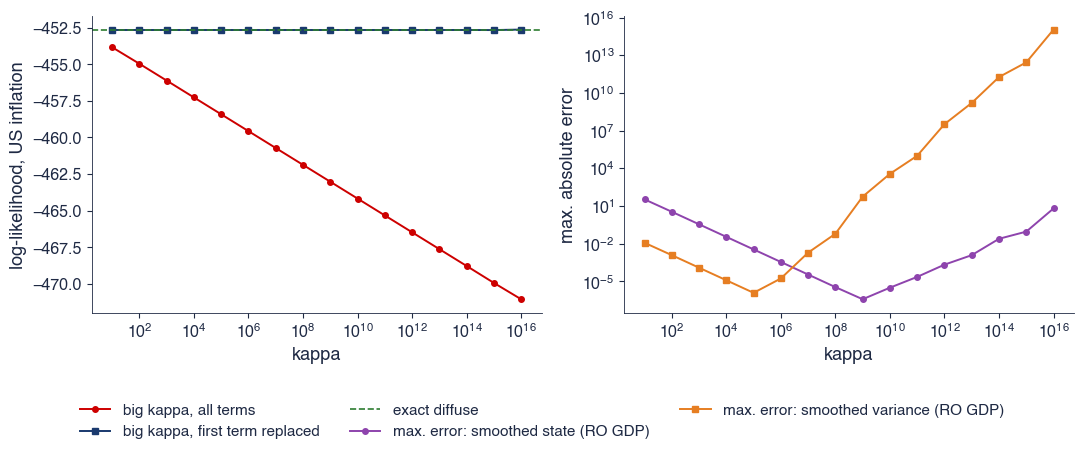

-452.66212680618617 1000000.0


In [6]:
def llt_model(s2eps, s2lev, s2slope):
    """Local linear trend: y_t = mu_t + eps_t, mu_{t+1} = mu_t + nu_t + xi_t, nu_{t+1} = nu_t + zeta_t."""
    return ssm([1.0, 0.0], [[1, 1], [0, 1]], np.eye(2), np.diag([s2lev, s2slope]), s2eps, Pinf=np.eye(2))


def fit_llt(y):
    """Exact diffuse ML of the local linear trend (three log-variances), numpy."""
    y = np.asarray(y, float)
    f = lambda th: -kalman_filter(y, llt_model(*np.exp(th)))['loglik']   # noqa: E731
    v = np.nanvar(np.diff(y))
    best = min((optimize.minimize(f, np.log(s), method='Nelder-Mead', options=dict(maxiter=4000, xatol=1e-7, fatol=1e-9))
                for s in ([v / 2, v / 2, v / 50], [v / 10, v, v / 100], [v, v / 10, v / 20])), key=lambda r: r.fun)
    best = optimize.minimize(f, best.x, method='BFGS')
    return dict(par=np.exp(best.x).tolist(), loglik=float(-best.fun))


def fig_diffuse(save_it=True):
    """Exact diffuse against big-kappa initialisation: the local level model for US inflation (log-likelihood) and the
    local linear trend for Romanian real GDP (accuracy of the smoothed states and variances)."""
    pi = us_inflation()
    ll = fit_local_level(pi.values)
    mod = local_level(ll['s2eps'], ll['s2eta'])
    exact = kalman_filter(pi.values, mod)['loglik']
    kap = 10.0 ** np.arange(1, 17)
    raw, adj = [], []
    for k in kap:
        L = kalman_filter(pi.values, big_kappa(mod, k))
        raw.append(L['loglik'])
        adj.append(L['loglik'] - L['ll'][0] - 0.5 * LOG2PI)      # first term replaced by the diffuse one (F_inf = 1)
    y = gdp_log('RO', '2000-01-01').values
    r = fit_llt(y)
    m2 = llt_model(*r['par'])
    ex = kalman_smoother(y, m2)
    ea, ev = [], []
    for k in kap:
        b = kalman_smoother(y, big_kappa(m2, k))
        ea.append(np.abs(b['alpha'] - ex['alpha']).max())
        ev.append(np.abs(b['V'] - ex['V']).max())
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.9))
    ax[0].semilogx(kap, raw, 'o-', color=st.IDAred, ms=4, label='big kappa, all terms')
    ax[0].semilogx(kap, adj, 's-', color=st.MainBlue, ms=4, label='big kappa, first term replaced')
    ax[0].axhline(exact, color=st.Forest, ls='--', lw=1.2, label='exact diffuse')
    ax[0].set_xlabel('kappa')
    ax[0].set_ylabel('log-likelihood, US inflation')
    ax[1].loglog(kap, np.maximum(ea, 1e-16), 'o-', color=st.Purple, ms=4, label='max. error: smoothed state (RO GDP)')
    ax[1].loglog(kap, np.maximum(ev, 1e-16), 's-', color=st.Orange, ms=4, label='max. error: smoothed variance (RO GDP)')
    ax[1].set_xlabel('kappa')
    ax[1].set_ylabel('max. absolute error')
    st.fig_legend_bottom(fig, ncol=3, y=-0.02)
    fig.tight_layout()
    save('ats_ch6_diffuse', save_it)
    ia, iv = np.array(ea), np.array(ev)
    return dict(exact=exact, raw=raw, adj=adj, kap=kap.tolist(), ea=ea, ev=ev, T_gdp=len(y),
                k_best=float(kap[int(np.argmin(ia + iv))]), err_best=float((ia + iv).min()), llt=r)


r = fig_diffuse(save_it=False)
print(r['exact'], r['k_best'])

## 2. Local level for US inflation: numpy against statsmodels

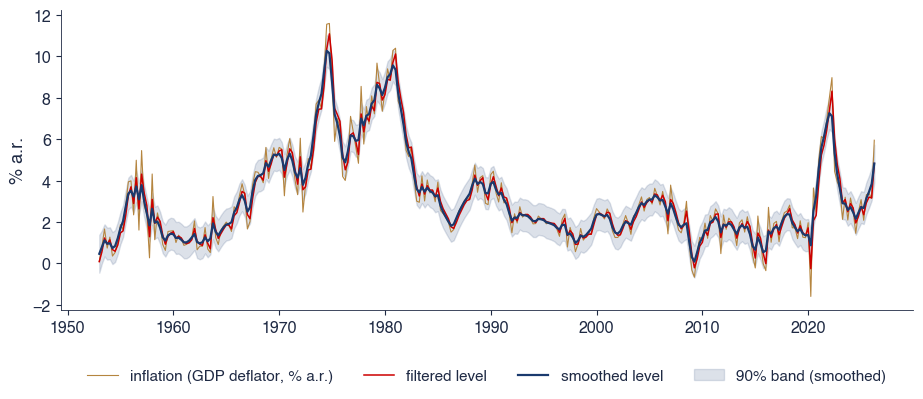

{'T': 294, 'first': '1953-01-01', 'last': '2026-04-01', 's2eps': 0.5168304429858223, 's2eta': 0.4531217232918991, 'q': 0.8767318749145919, 'll': -452.66212680618617, 'se_log': [0.15023043623672933, 0.18977450085666023], 'sm_s2eps': 0.5168180906568025, 'sm_s2eta': 0.4531222506008681, 'sm_ll': -451.7431882891134, 'll_gap': -0.9189385170727746, 'd': 1, 't_np': 0.24884390830993652, 't_sm': 0.004842996597290039, 'last_level': 4.826403830677899, 'last_sd': 0.5547765101804727, 'last_filt': 4.826403830677899, 'steady_K': 0.5955086052399338}


In [7]:
def fig_local_level(save_it=True):
    """Local level model for US GDP-deflator inflation: numpy exact diffuse ML against statsmodels
    UnobservedComponents; filtered and smoothed level with 90% bands."""
    import statsmodels.api as sm
    pi = us_inflation()
    t0 = time.time()
    r = fit_local_level(pi.values)
    t_np = time.time() - t0
    t0 = time.time()
    res = sm.tsa.UnobservedComponents(pi.values, 'llevel').fit(disp=False)
    t_sm = time.time() - t0
    mod = local_level(r['s2eps'], r['s2eta'])
    sm_ = kalman_smoother(pi.values, mod)
    kf = sm_['kf']
    # filtered level a_{t|t} = a_t + P_t v_t / F_t; for the diffuse first observation a_{1|1} = y_1
    filt = kf['a'][:, 0] + np.where(kf['diffuse'], 1.0, kf['P'][:, 0, 0] / kf['F']) * kf['v']
    z = stats.norm.ppf(0.95)
    sd = np.sqrt(sm_['V'][:, 0, 0])
    fig, ax = plt.subplots(figsize=(11, 3.9))
    ax.plot(pi.index, pi.values, color=st.Amber, lw=0.8, label='inflation (GDP deflator, % a.r.)')
    ax.plot(pi.index, filt, color=st.IDAred, lw=1.1, label='filtered level')
    ax.plot(pi.index, sm_['alpha'][:, 0], color=st.MainBlue, lw=1.6, label='smoothed level')
    ax.fill_between(pi.index, sm_['alpha'][:, 0] - z * sd, sm_['alpha'][:, 0] + z * sd, color=st.MainBlue, alpha=0.15,
                    label='90% band (smoothed)')
    ax.set_ylabel('% a.r.')
    st.legend_outside_bottom(ax, ncol=4, y=-0.15)
    save('ats_ch6_local_level', save_it)
    return dict(T=len(pi), first=str(pi.index[0].date()), last=str(pi.index[-1].date()), s2eps=r['s2eps'],
                s2eta=r['s2eta'], q=r['q'], ll=r['loglik'], se_log=r['se_log'], sm_s2eps=float(res.params[0]),
                sm_s2eta=float(res.params[1]), sm_ll=float(res.llf), ll_gap=float(r['loglik'] - res.llf),
                d=int(kf['d']), t_np=t_np, t_sm=t_sm, last_level=float(sm_['alpha'][-1, 0]), last_sd=float(sd[-1]),
                last_filt=float(filt[-1]), steady_K=float(kf['K0'][-1, 0]))


print(fig_local_level(save_it=False))

## 3. The pile-up problem

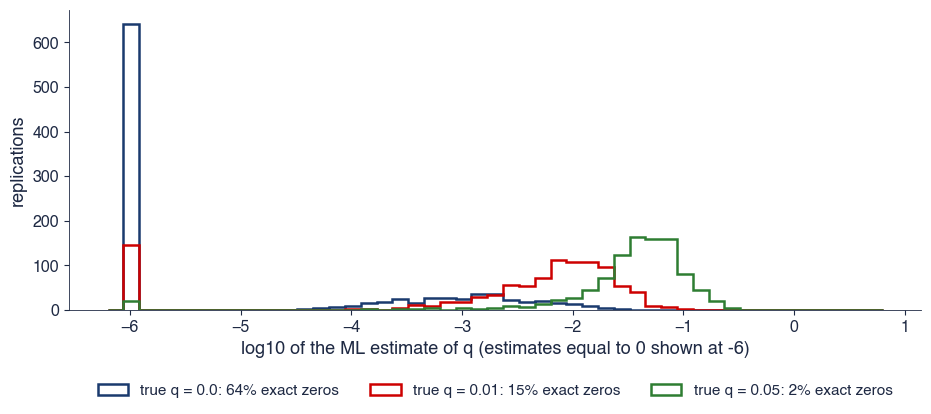

{'0.0': {'zero': 0.641, 'median': 0.0, 'mean': 0.0010635372737670104}, '0.01': {'zero': 0.146, 'median': 0.007428646653163292, 'mean': 0.010758920581028524}, '0.05': {'zero': 0.021, 'median': 0.04387315585883132, 'mean': 0.0539401056547794}, 'reps': 1000, 'n': 100}


In [8]:
def ll_profile(Y, qgrid):
    """Concentrated diffuse log-likelihood of the local level model for many series at once (rows of Y) and a grid
    of signal-to-noise ratios q = s2eta / s2eps (columns): sigma_eps^2 concentrated out (Durbin and Koopman 2012,
    Section 7.3); the constant terms are dropped."""
    R, n = Y.shape
    G = len(qgrid)
    a = np.repeat(Y[:, :1], G, axis=1)          # after the diffuse first observation: a_2 = y_1, P_2 = 1 + q
    P = np.ones((R, G)) + qgrid[None, :]
    s, lf = np.zeros((R, G)), np.zeros((R, G))
    for t in range(1, n):
        v = Y[:, t:t + 1] - a
        F = P + 1.0
        s += v ** 2 / F
        lf += np.log(F)
        K = P / F
        a = a + K * v
        P = P * (1 - K) + qgrid[None, :]
    m = n - 1
    s2 = s / m
    return -0.5 * m * np.log(s2) - 0.5 * lf, s2


def fig_pileup(save_it=True, reps=4000, n=100):
    """Pile-up of the ML estimate of q = s2eta / s2eps at zero in the local level model (Shephard and Harvey 1990):
    share of exact zeros for true q in {0, 0.01, 0.05}, T = 100, by simulation (profile likelihood on a fine grid)."""
    rng = np.random.default_rng(SEED)
    qgrid = np.concatenate([[0.0], np.exp(np.linspace(np.log(1e-5), np.log(5.0), 400))])
    out = {}
    fig, ax = plt.subplots(figsize=(11, 3.9))
    cols = {0.0: st.MainBlue, 0.01: st.IDAred, 0.05: st.Forest}
    for q in (0.0, 0.01, 0.05):
        Y = np.cumsum(rng.normal(0, np.sqrt(q), (reps, n)), axis=1) + rng.normal(0, 1, (reps, n))
        L, _ = ll_profile(Y, qgrid)
        qh = qgrid[np.argmax(L, axis=1)]
        out[str(q)] = dict(zero=float(np.mean(qh == 0)), median=float(np.median(qh)), mean=float(np.mean(qh)))
        x = np.log10(np.maximum(qh, 1e-6))
        ax.hist(x, bins=np.linspace(-6.2, 0.8, 50), histtype='step', lw=1.8, color=cols[q],
                label=f'true q = {q}: {100 * np.mean(qh == 0):.0f}% exact zeros')
    ax.set_xlabel('log10 of the ML estimate of q (estimates equal to 0 shown at -6)')
    ax.set_ylabel('replications')
    st.legend_outside_bottom(ax, ncol=3, y=-0.2)
    save('ats_ch6_pileup', save_it)
    return dict(out, reps=reps, n=n)


print(fig_pileup(save_it=False, reps=1000))

## 4. Three samplers of the same posterior; Gibbs for the local level

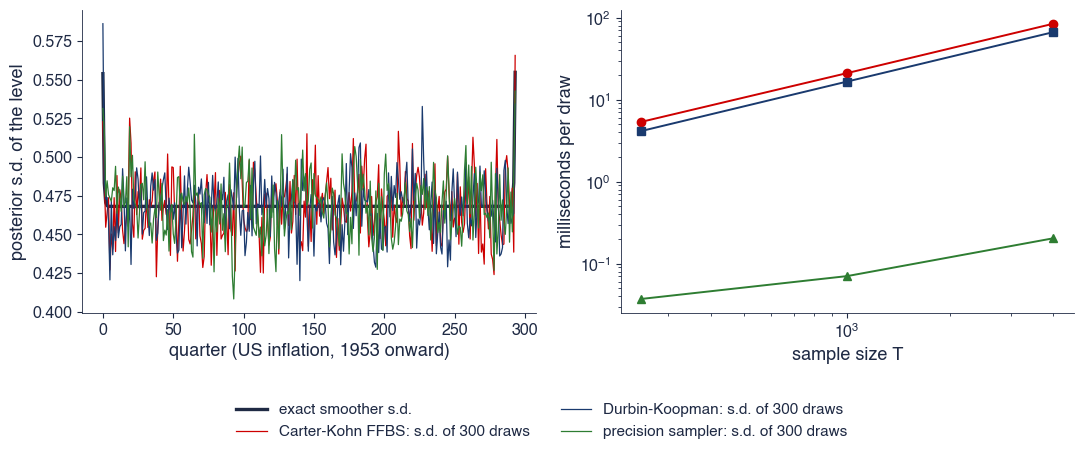

{'res': {'ck': {'mean_err': 0.07820141930411362, 'sd_ratio_min': 0.9028183512193384, 'sd_ratio_max': 1.1218796740119314}, 'dk': {'mean_err': 0.10078758174864921, 'sd_ratio_min': 0.8974572940168797, 'sd_ratio_max': 1.138045373841779}, 'pr': {'mean_err': 0.0900872531703385, 'sd_ratio_min': 0.8721657596509542, 'sd_ratio_max': 1.110130956749081}}, 'ms': {'ck': [5.354154109954834, 21.08525037765503, 84.28088426589966], 'dk': [4.140603542327881, 16.63334369659424, 66.55304431915283], 'pr': [0.0372004508972168, 0.07071137428283691, 0.2043592929840088]}, 'sizes': [250, 1000, 4000], 'draws': 300, 'tm': {'ck': 0.006562449932098389, 'dk': 0.004885869820912679, 'pr': 4.1383107503255206e-05}}


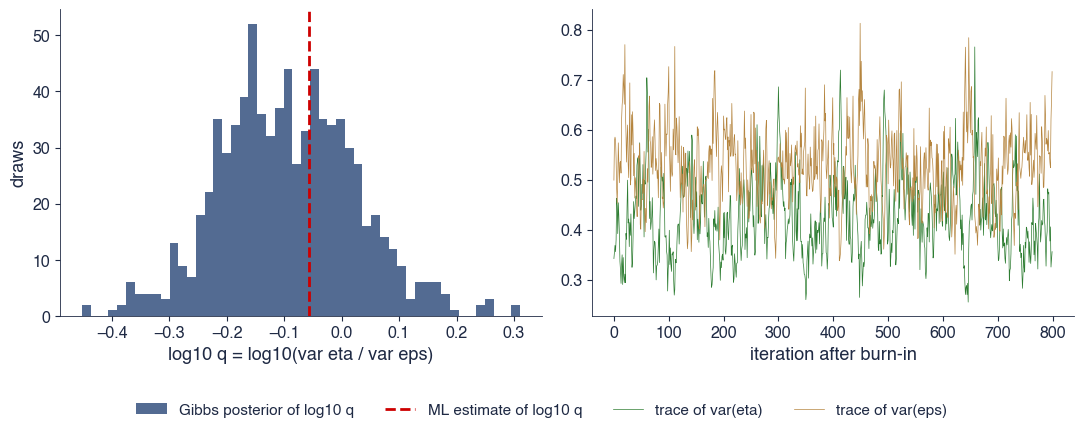

{'post_mean': [0.5265200268926171, 0.42763540232730096], 'post_q_med': 0.7977508631622559, 'q_lo': 0.5237220544135082, 'q_hi': 1.2576512865621476, 'ml': [0.5168304429858223, 0.4531217232918991], 'ml_q': 0.8767318749145919, 'ineff': [2.4686983359260903, 3.363098831938104], 'draws': 800, 'burn': 200}


In [9]:
def fig_simsmoother(save_it=True, draws=2000):
    """Three samplers of p(mu | y) in the local level model (US inflation, ML variances, proper prior N(y_1, 100)):
    Carter-Kohn FFBS, Durbin-Koopman mean correction, precision sampler. Draw means and standard deviations
    against the exact smoother; time per draw for growing samples."""
    rng = np.random.default_rng(SEED)
    pi = us_inflation().values
    r = fit_local_level(pi)
    mod = ssm([1.0], [[1.0]], [[1.0]], [[r['s2eta']]], r['s2eps'], a1=[pi[0]], P1=[[100.0]])
    ex = kalman_smoother(pi, mod)
    m_ex, s_ex = ex['alpha'][:, 0], np.sqrt(ex['V'][:, 0, 0])
    res, tm = {}, {}
    for name, f in (('ck', lambda: ffbs(pi, mod, rng)[:, 0]), ('dk', lambda: sim_smoother_dk(pi, mod, rng)[:, 0]),
                    ('pr', lambda: precision_rw(pi, r['s2eps'], r['s2eta'], pi[0], 100.0, rng))):
        t0 = time.time()
        D = np.array([f() for _ in range(draws)])
        tm[name] = (time.time() - t0) / draws
        res[name] = dict(mean_err=float(np.abs(D.mean(0) - m_ex).max()), sd_ratio_min=float((D.std(0) / s_ex).min()),
                         sd_ratio_max=float((D.std(0) / s_ex).max()), sd=D.std(0))
    # time per draw for longer simulated samples
    sizes = [250, 1000, 4000]
    timing = {k: [] for k in ('ck', 'dk', 'pr')}
    for n in sizes:
        ys = np.cumsum(rng.normal(0, np.sqrt(r['s2eta']), n)) + rng.normal(0, np.sqrt(r['s2eps']), n)
        md = ssm([1.0], [[1.0]], [[1.0]], [[r['s2eta']]], r['s2eps'], a1=[ys[0]], P1=[[100.0]])
        for k, f in (('ck', lambda: ffbs(ys, md, rng)), ('dk', lambda: sim_smoother_dk(ys, md, rng)),
                     ('pr', lambda: precision_rw(ys, r['s2eps'], r['s2eta'], ys[0], 100.0, rng))):
            reps = 20 if k != 'pr' else 200
            t0 = time.time()
            for _ in range(reps):
                f()
            timing[k].append((time.time() - t0) / reps * 1000)
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.9))
    x = np.arange(len(pi))
    ax[0].plot(x, s_ex, color=st.DarkText, lw=2.4, label='exact smoother s.d.')
    for k, c, lab in (('ck', st.IDAred, 'Carter-Kohn FFBS'), ('dk', st.MainBlue, 'Durbin-Koopman'),
                      ('pr', st.Forest, 'precision sampler')):
        ax[0].plot(x, res[k]['sd'], color=c, lw=0.9, label=f'{lab}: s.d. of {draws} draws')
    ax[0].set_xlabel('quarter (US inflation, 1953 onward)')
    ax[0].set_ylabel('posterior s.d. of the level')
    for k, c, mk in (('ck', st.IDAred, 'o'), ('dk', st.MainBlue, 's'), ('pr', st.Forest, '^')):
        ax[1].loglog(sizes, timing[k], marker=mk, color=c, lw=1.4)
    ax[1].set_xlabel('sample size T')
    ax[1].set_ylabel('milliseconds per draw')
    st.fig_legend_bottom(fig, ncol=2, y=-0.02)
    fig.tight_layout()
    save('ats_ch6_simsmoother', save_it)
    for k in res:
        res[k].pop('sd')
    return dict(res=res, ms=timing, sizes=sizes, draws=draws, tm=tm)


def gibbs_local_level(y, draws=3000, burn=500, prior=(2.5, 0.25), rng=None):
    """Gibbs sampler for the local level model: (1) mu | variances, y by the Durbin-Koopman simulation smoother
    (exact diffuse mu_1); (2) s2eps | mu, y and s2eta | mu are inverse gamma, IG(a0 + n/2, b0 + SS/2)."""
    rng = rng or np.random.default_rng(SEED)
    y = np.asarray(y, float)
    n = len(y)
    a0, b0 = prior
    s2e, s2h = np.var(np.diff(y)) / 2, np.var(np.diff(y)) / 2
    out = np.zeros((draws, 2))
    for it in range(draws + burn):
        mu = sim_smoother_dk(y, local_level(s2e, s2h), rng)[:, 0]
        e, h = y - mu, np.diff(mu)
        s2e = 1 / rng.gamma(a0 + n / 2, 1 / (b0 + e @ e / 2))
        s2h = 1 / rng.gamma(a0 + (n - 1) / 2, 1 / (b0 + h @ h / 2))
        if it >= burn:
            out[it - burn] = s2e, s2h
    return out


def fig_gibbs_ll(save_it=True, draws=3000, burn=500):
    """Gibbs posterior of the local level variances for US inflation against the ML estimates."""
    pi = us_inflation().values
    r = fit_local_level(pi)
    D = gibbs_local_level(pi, draws, burn)
    q = D[:, 1] / D[:, 0]
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.9))
    ax[0].hist(np.log10(q), bins=50, color=st.MainBlue, alpha=0.75, label='Gibbs posterior of log10 q')
    ax[0].axvline(np.log10(r['q']), color=st.IDAred, lw=2, ls='--', label='ML estimate of log10 q')
    ax[0].set_xlabel('log10 q = log10(var eta / var eps)')
    ax[0].set_ylabel('draws')
    ax[1].plot(D[:, 1], color=st.Forest, lw=0.5, label='trace of var(eta)')
    ax[1].plot(D[:, 0], color=st.Amber, lw=0.5, label='trace of var(eps)')
    ax[1].set_xlabel('iteration after burn-in')
    st.fig_legend_bottom(fig, ncol=4, y=-0.02)
    fig.tight_layout()
    save('ats_ch6_gibbs_ll', save_it)
    return dict(post_mean=D.mean(0).tolist(), post_q_med=float(np.median(q)), q_lo=float(np.quantile(q, 0.05)),
                q_hi=float(np.quantile(q, 0.95)), ml=[r['s2eps'], r['s2eta']], ml_q=r['q'],
                ineff=[ineff(D[:, 0]), ineff(D[:, 1])], draws=draws, burn=burn)


print(fig_simsmoother(save_it=False, draws=300))
print(fig_gibbs_ll(save_it=False, draws=800, burn=200))

## 5. Stochastic volatility: KSC mixture, Gibbs sampler, particle filter

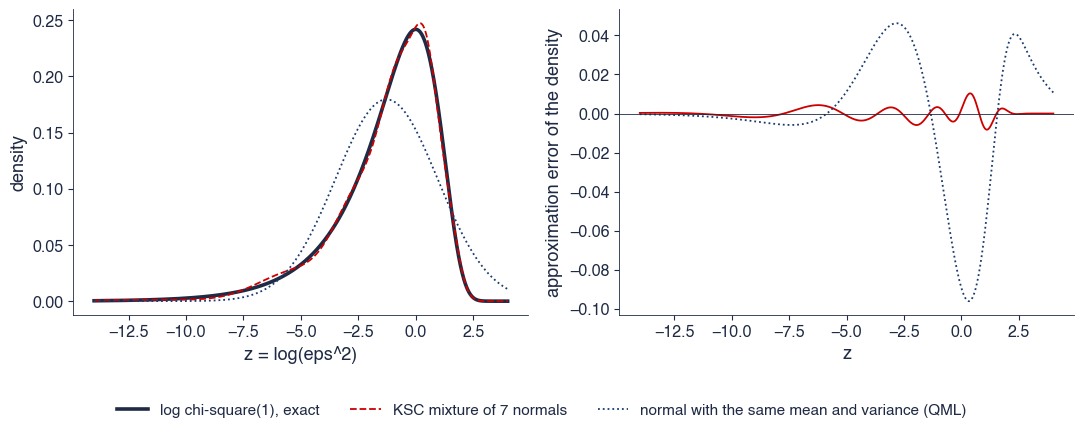

{'mean_mix': -1.2703991528, 'var_mix': 4.934854401149436, 'mean_exact': -1.2704, 'var_exact': 4.934802200544679, 'maxerr_mix': 0.010325105220825637, 'maxerr_gauss': 0.09617034219576032}


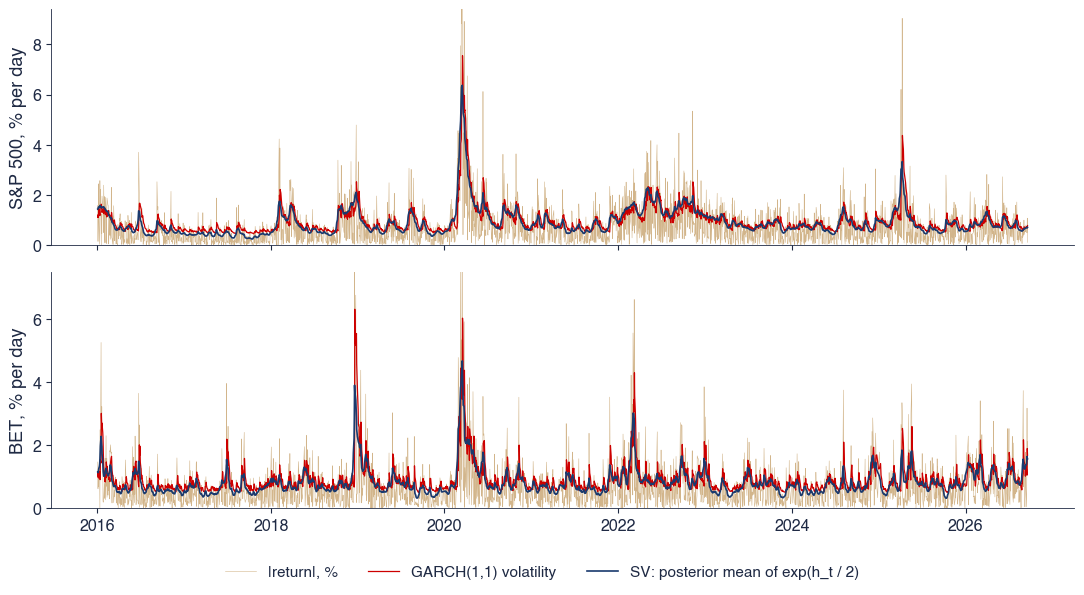

{'sp500': [-0.4637146582042713, 0.9625396217447824, 0.2912619183756432], 'bet': [-0.6255077709906197, 0.9158277193955676, 0.3884889972042453]}


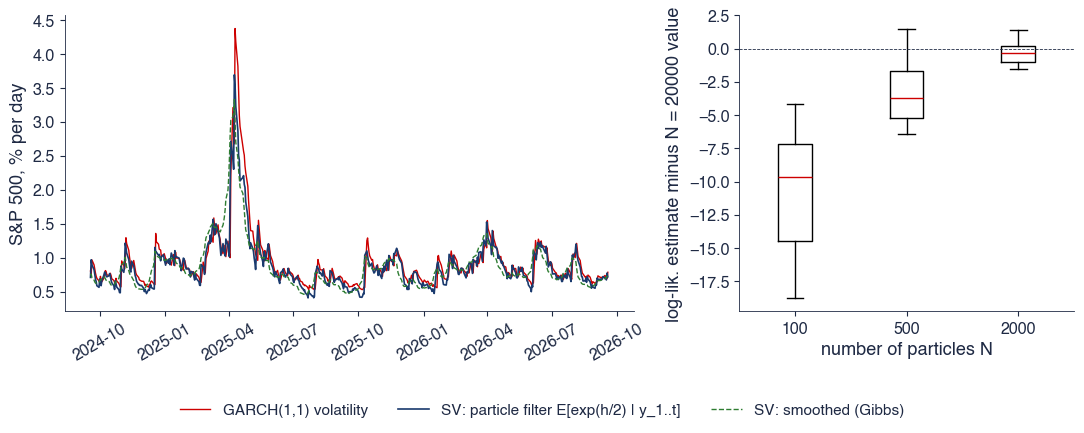

{'ll_sv': -3378.7307422117537, 'll_garch': -3467.288531766995, 'sd': {'100': 4.67169156179774, '500': 2.3421319287066225, '2000': 0.8423289148220493}, 'theta': [-0.4637146582042713, 0.9625396217447824, 0.2912619183756432], 'reps': 10, 'ess_min': 134.49508833610014, 'ess_med': 18716.487432831396, 'T': 2692, 'corr_pf_garch': 0.9574313603203837, 'aic_sv': 6763.4614844235075, 'aic_garch': 6940.57706353399}


In [10]:
def fig_ksc(save_it=True):
    """Density of z = log(eps^2), eps ~ N(0, 1) (log chi-square(1)) against the seven-component normal mixture of
    Kim, Shephard and Chib (1998), means shifted by -1.2704."""
    z = np.linspace(-14, 4, 1200)
    exact = np.exp(0.5 * (z - np.exp(z))) / np.sqrt(2 * np.pi)
    mix = sum(p * stats.norm.pdf(z, m - 1.2704, np.sqrt(v)) for p, m, v in zip(KSC_P, KSC_M, KSC_V))
    gauss = stats.norm.pdf(z, -1.2704, np.sqrt(np.pi ** 2 / 2))
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.9))
    ax[0].plot(z, exact, color=st.DarkText, lw=2.6, label='log chi-square(1), exact')
    ax[0].plot(z, mix, color=st.IDAred, lw=1.3, ls='--', label='KSC mixture of 7 normals')
    ax[0].plot(z, gauss, color=st.MainBlue, lw=1.3, ls=':', label='normal with the same mean and variance (QML)')
    ax[0].set_xlabel('z = log(eps^2)')
    ax[0].set_ylabel('density')
    ax[1].plot(z, mix - exact, color=st.IDAred, lw=1.3)
    ax[1].plot(z, gauss - exact, color=st.MainBlue, lw=1.3, ls=':')
    ax[1].axhline(0, color=st.DarkText, lw=0.6)
    ax[1].set_xlabel('z')
    ax[1].set_ylabel('approximation error of the density')
    st.fig_legend_bottom(fig, ncol=3, y=-0.02)
    fig.tight_layout()
    save('ats_ch6_ksc', save_it)
    mean_mix = float((KSC_P * (KSC_M - 1.2704)).sum())
    var_mix = float((KSC_P * (KSC_V + (KSC_M - 1.2704) ** 2)).sum() - mean_mix ** 2)
    return dict(mean_mix=mean_mix, var_mix=var_mix, mean_exact=float(-1.2704), var_exact=float(np.pi ** 2 / 2),
                maxerr_mix=float(np.abs(mix - exact).max()), maxerr_gauss=float(np.abs(gauss - exact).max()))


def fig_sv(save_it=True, draws=6000, burn=1000):
    """SV by Gibbs (KSC) for the S&P 500 and the BET, daily % returns since 2016: posterior mean of exp(h_t/2)
    against the GARCH(1,1) volatility; posterior table and inefficiency factors."""
    out = {}
    fig, ax = plt.subplots(2, 1, figsize=(11, 5.6), sharex=True)
    for i, (name, lab) in enumerate((('sp500', 'S&P 500'), ('bet', 'BET'))):
        r = returns(name)
        g = sv_gibbs(r.values, draws, burn, rng=np.random.default_rng(SEED + i))
        ga = garch11(r.values)
        th = g['theta']
        out[name] = dict(T=len(r), first=str(r.index[0].date()), last=str(r.index[-1].date()),
                         mean=th.mean(0).tolist(), sd=th.std(0).tolist(), lo=np.quantile(th, 0.05, 0).tolist(),
                         hi=np.quantile(th, 0.95, 0).tolist(), ineff=[ineff(th[:, j]) for j in range(3)],
                         acc=g['acc_phi'], garch=dict(omega=ga['omega'], alpha=ga['alpha'], beta=ga['beta'],
                                                       loglik=ga['loglik']),
                         corr_vol=float(np.corrcoef(g['vol'], ga['sigma'])[0, 1]),
                         kurt=float(stats.kurtosis(r.values, fisher=False)))
        a = ax[i]
        a.plot(r.index, np.abs(r.values), color=st.Amber, lw=0.4, alpha=0.6, label='|return|, %')
        a.plot(r.index, ga['sigma'], color=st.IDAred, lw=0.9, label='GARCH(1,1) volatility')
        a.plot(r.index, g['vol'], color=st.MainBlue, lw=1.2, label='SV: posterior mean of exp(h_t / 2)')
        a.set_ylim(0, np.quantile(np.abs(r.values), 0.999) * 1.05)
        a.set_ylabel(f'{lab}, % per day')
        _sv_cache[name] = dict(r=r, g=g, ga=ga)
    st.fig_legend_bottom(fig, ncol=3, y=-0.0)
    fig.tight_layout()
    save('ats_ch6_sv', save_it)
    out['draws'], out['burn'] = draws, burn
    return out


def fig_pf(save_it=True, Ns=(100, 500, 2000), reps=40):
    """Bootstrap particle filter for the SV model of the S&P 500 at the Gibbs posterior mean: filtered volatility
    against GARCH(1,1) over the last two years; Monte Carlo spread of the log-likelihood estimate against N;
    SV log-likelihood against the GARCH maximum."""
    rng = np.random.default_rng(SEED)
    if 'sp500' not in _sv_cache:
        r = returns('sp500')
        _sv_cache['sp500'] = dict(r=r, g=sv_gibbs(r.values, 3000, 500, rng=np.random.default_rng(SEED)), ga=garch11(r.values))
    c = _sv_cache['sp500']
    r, th, ga = c['r'], c['g']['theta'].mean(0), c['ga']
    big = pf_sv(r.values, *th, N=20000, rng=rng)
    lls = {N: [pf_sv(r.values, *th, N=N, rng=rng, store=False)['loglik'] for _ in range(reps)] for N in Ns}
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.9), gridspec_kw=dict(width_ratios=[1.7, 1]))
    k = r.index >= r.index[-1] - pd.Timedelta(days=730)
    ax[0].plot(r.index[k], ga['sigma'][k], color=st.IDAred, lw=1.0, label='GARCH(1,1) volatility')
    ax[0].plot(r.index[k], big['vol'][k], color=st.MainBlue, lw=1.2, label='SV: particle filter E[exp(h/2) | y_1..t]')
    ax[0].plot(r.index[k], c['g']['vol'][k], color=st.Forest, lw=1.0, ls='--', label='SV: smoothed (Gibbs)')
    ax[0].set_ylabel('S&P 500, % per day')
    ax[0].tick_params(axis='x', labelrotation=30)
    ax[1].boxplot([np.array(lls[N]) - big['loglik'] for N in Ns], labels=[str(N) for N in Ns])
    ax[1].axhline(0, color=st.DarkText, lw=0.6, ls='--')
    ax[1].set_xlabel('number of particles N')
    ax[1].set_ylabel('log-lik. estimate minus N = 20000 value')
    st.fig_legend_bottom(fig, ncol=3, y=-0.02)
    fig.tight_layout()
    save('ats_ch6_pf', save_it)
    sd = {str(N): float(np.std(lls[N])) for N in Ns}
    return dict(ll_sv=big['loglik'], ll_garch=ga['loglik'], sd=sd, theta=th.tolist(), reps=reps,
                ess_min=float(big['ess'].min()), ess_med=float(np.median(big['ess'])), T=len(r),
                corr_pf_garch=float(np.corrcoef(big['vol'], ga['sigma'])[0, 1]),
                aic_sv=float(-2 * big['loglik'] + 6), aic_garch=float(-2 * ga['loglik'] + 6))


print(fig_ksc(save_it=False))
r = fig_sv(save_it=False, draws=3000, burn=500)
print({k: r[k]['mean'] for k in ('sp500', 'bet')})
print(fig_pf(save_it=False, reps=10))

## 6. PMMH against Gibbs (short run)

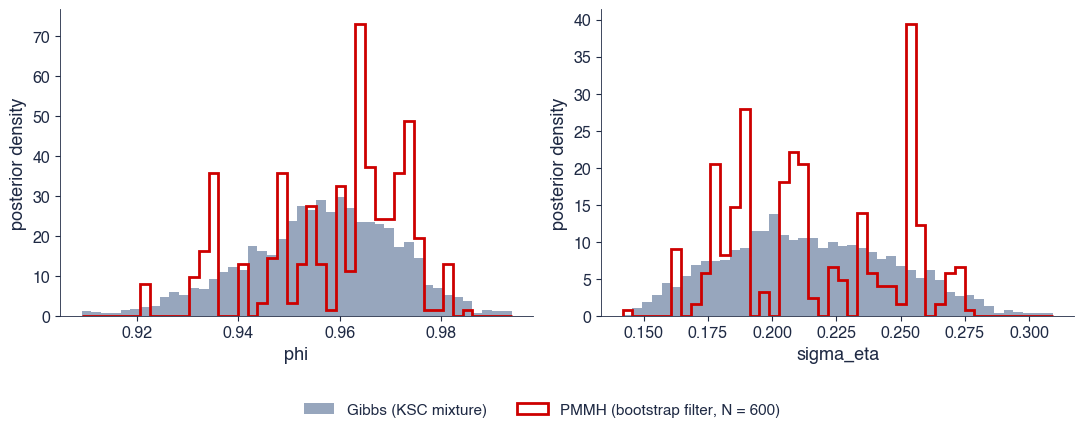

{'n': 1000, 'first': '2022-09-23', 'last': '2026-09-18', 'N': 600, 'n_iter': 400, 'acc': 0.1575, 'gibbs_mean': [-0.3666479154069689, 0.9561340497394877, 0.21451170681347972], 'pmmh_mean': [-0.4004968810604225, 0.9592566811284458, 0.21571259335475776], 'gibbs_sd': [0.19308818794056357, 0.014967621979080036, 0.03306894125919329], 'pmmh_sd': [0.19627532049817972, 0.013918097105530663, 0.0317815462802744], 'sd_ll': 1.5526785987954699, 'secs': 8.688995122909546, 'ineff_pmmh': [16.80858366984704, 15.941112166318888, 17.028828663915952], 'ineff_gibbs': [2.4059208115168174, 23.36069083484702, 43.21128633085582]}


In [11]:
def pmmh_sv(y, n_iter=3000, N=600, cov=None, start=None, rng=None):
    """Particle marginal Metropolis-Hastings (Andrieu, Doucet and Holenstein 2010) for (mu, phi, sigma) of the SV
    model: Gaussian random walk on (mu, atanh phi, log sigma); the exact likelihood is replaced by the bootstrap
    particle filter estimate; KSC priors with the Jacobian of the transformation."""
    rng = rng or np.random.default_rng(SEED)

    def logprior(z):
        mu, ph, sg = z[0], np.tanh(z[1]), np.exp(z[2])
        return (stats.norm.logpdf(mu, 0, np.sqrt(10)) + stats.beta.logpdf((ph + 1) / 2, 20, 1.5)
                + stats.invgamma.logpdf(sg ** 2, 2.5, scale=0.025) + np.log(1 - ph ** 2) + np.log(2 * sg ** 2))

    def tr(z):
        return z[0], np.tanh(z[1]), np.exp(z[2])
    z = np.array(start)
    ll = pf_sv(y, *tr(z), N=N, rng=rng, store=False)['loglik']
    lp = logprior(z)
    Lc = np.linalg.cholesky(cov)
    out, acc = np.zeros((n_iter, 3)), 0
    for it in range(n_iter):
        zp = z + Lc @ rng.standard_normal(3)
        llp = pf_sv(y, *tr(zp), N=N, rng=rng, store=False)['loglik']
        lpp = logprior(zp)
        if np.log(rng.random()) < llp + lpp - ll - lp:
            z, ll, lp = zp, llp, lpp
            acc += 1
        out[it] = tr(z)
    return out, acc / n_iter


def fig_pmmh(save_it=True, n_last=1000, n_iter=3000, N=600, draws=6000):
    """PMMH against the KSC Gibbs sampler on the last n_last S&P 500 returns: two exact algorithms, one posterior."""
    r = returns('sp500').iloc[-n_last:]
    r = r - r.mean()
    g = sv_gibbs(r.values, draws, 1000, rng=np.random.default_rng(SEED + 7), keep_h=False)
    th = g['theta']
    zt = np.column_stack([th[:, 0], np.arctanh(th[:, 1]), np.log(th[:, 2])])
    cov = np.cov(zt.T) * 2.38 ** 2 / 3
    t0 = time.time()
    P, acc = pmmh_sv(r.values, n_iter, N, cov=cov, start=zt.mean(0), rng=np.random.default_rng(SEED + 8))
    secs = time.time() - t0
    burn = n_iter // 5
    P = P[burn:]
    sd_ll = float(np.std([pf_sv(r.values, *th.mean(0), N=N, rng=np.random.default_rng(i), store=False)['loglik']
                          for i in range(30)]))
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.9))
    for j, (a, lab) in enumerate(((ax[0], 'phi'), (ax[1], 'sigma_eta'))):
        k = j + 1
        lo, hi = np.quantile(np.r_[th[:, k], P[:, k]], [0.002, 0.998])
        bins = np.linspace(lo, hi, 45)
        a.hist(th[:, k], bins=bins, density=True, color=st.MainBlue, alpha=0.45, label='Gibbs (KSC mixture)')
        a.hist(P[:, k], bins=bins, density=True, histtype='step', lw=2, color=st.IDAred,
               label=f'PMMH (bootstrap filter, N = {N})')
        a.set_xlabel(lab)
        a.set_ylabel('posterior density')
    st.fig_legend_bottom(fig, ncol=2, y=-0.02)
    fig.tight_layout()
    save('ats_ch6_pmmh', save_it)
    return dict(n=n_last, first=str(r.index[0].date()), last=str(r.index[-1].date()), N=N, n_iter=n_iter, acc=acc,
                gibbs_mean=th.mean(0).tolist(), pmmh_mean=P.mean(0).tolist(), gibbs_sd=th.std(0).tolist(),
                pmmh_sd=P.std(0).tolist(), sd_ll=sd_ll, secs=secs, ineff_pmmh=[ineff(P[:, j]) for j in range(3)],
                ineff_gibbs=[ineff(th[:, j]) for j in range(3)])


print(fig_pmmh(save_it=False, n_iter=400, N=600, draws=3000))

## 7. Unscented transform and particle filters against the exact likelihood

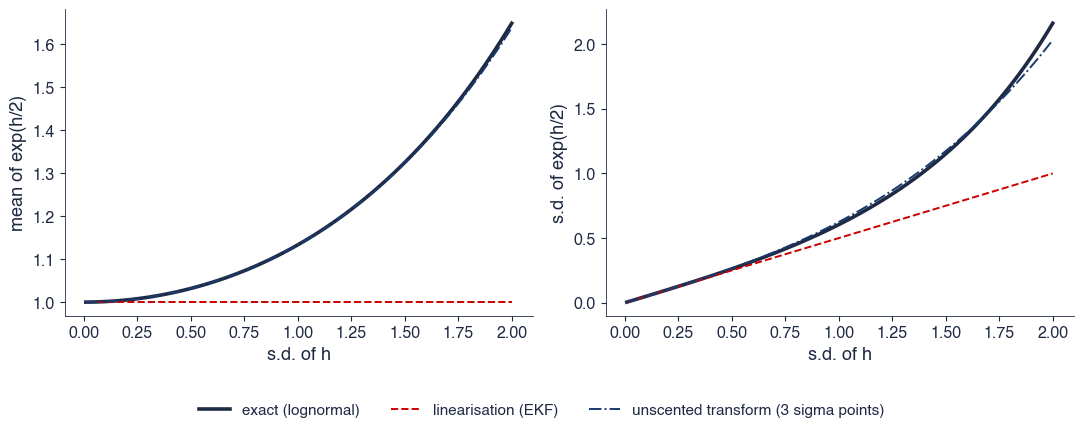

{'s': 0.9924050632911392, 'ex_m': 1.1310071016524483, 'lin_m': 1.0, 'ut_m': 1.130875385468969, 'ex_sd': 0.5975925844966478, 'lin_sd': 0.4962025316455696, 'ut_sd': 0.6177777404451356}


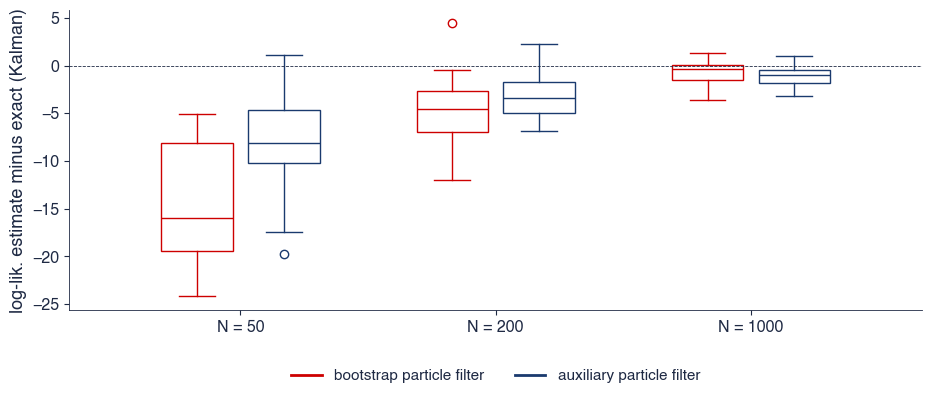

{'bootstrap': {'50': {'mean': -14.649038298787351, 'sd': 5.943686009262679, 'lvl_bias': -7.629073806264011}, '200': {'mean': -4.613969383018057, 'sd': 3.259172598326591, 'lvl_bias': 1.049648790536005}, '1000': {'mean': -0.6748154569143822, 'sd': 1.3078342911763137, 'lvl_bias': -0.008704885716576955}}, 'auxiliary': {'50': {'mean': -8.100581901755167, 'sd': 4.7795903621205795, 'lvl_bias': -2.060830453515411}, '200': {'mean': -3.268325235774942, 'sd': 2.3818173037787345, 'lvl_bias': -0.2753554699205281}, '1000': {'mean': -1.072526870161291, 'sd': 1.1059009825863895, 'lvl_bias': -0.49598948385828995}}, 'exact': -451.7431882729815, 'reps': 30}


In [12]:
def unscented(m, P, g, alpha=1.0, beta=2.0, kappa=None):
    """Unscented transform of N(m, P) through g (Julier and Uhlmann 2004): 2n + 1 sigma points, mean and covariance."""
    m = np.atleast_1d(np.asarray(m, float))
    P = np.atleast_2d(np.asarray(P, float))
    n = len(m)
    kappa = 3.0 - n if kappa is None else kappa
    lam = alpha ** 2 * (n + kappa) - n
    S = np.linalg.cholesky((n + lam) * P)
    X = np.vstack([m, m + S.T, m - S.T])
    wm = np.r_[lam / (n + lam), np.full(2 * n, 1 / (2 * (n + lam)))]
    wc = wm.copy()
    wc[0] += 1 - alpha ** 2 + beta
    Y = np.array([np.atleast_1d(g(x)) for x in X])
    my = wm @ Y
    D = Y - my
    return my, (wc[:, None] * D).T @ D


def fig_ukf(save_it=True):
    """Mean and standard deviation of exp(h/2) for h ~ N(m, s^2) (volatility from log-variance): exact (lognormal),
    first-order linearisation (extended Kalman filter) and the unscented transform."""
    s = np.linspace(0.01, 2.0, 80)
    m = 0.0
    ex_m = np.exp(m / 2 + s ** 2 / 8)
    ex_sd = np.sqrt((np.exp(s ** 2 / 4) - 1) * np.exp(m + s ** 2 / 4))
    lin_m = np.full_like(s, np.exp(m / 2))
    lin_sd = 0.5 * np.exp(m / 2) * s
    ut = [unscented([m], [[x ** 2]], lambda h: np.exp(h / 2)) for x in s]
    ut_m = np.array([u[0][0] for u in ut])
    ut_sd = np.array([np.sqrt(u[1][0, 0]) for u in ut])
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.9))
    for a, e, l_, u, lab in ((ax[0], ex_m, lin_m, ut_m, 'mean of exp(h/2)'), (ax[1], ex_sd, lin_sd, ut_sd, 's.d. of exp(h/2)')):
        a.plot(s, e, color=st.DarkText, lw=2.6, label='exact (lognormal)')
        a.plot(s, l_, color=st.IDAred, lw=1.4, ls='--', label='linearisation (EKF)')
        a.plot(s, u, color=st.MainBlue, lw=1.4, ls='-.', label='unscented transform (3 sigma points)')
        a.set_xlabel('s.d. of h')
        a.set_ylabel(lab)
    st.fig_legend_bottom(fig, ncol=3, y=-0.02)
    fig.tight_layout()
    save('ats_ch6_ukf', save_it)
    i = np.argmin(np.abs(s - 1.0))
    return dict(s=float(s[i]), ex_m=float(ex_m[i]), lin_m=float(lin_m[i]), ut_m=float(ut_m[i]), ex_sd=float(ex_sd[i]),
                lin_sd=float(lin_sd[i]), ut_sd=float(ut_sd[i]))


def pf_local_level(y, s2eps, s2eta, N, rng, auxiliary=False):
    """Bootstrap or auxiliary (Pitt and Shephard 1999) particle filter for the local level model; returns the
    log-likelihood estimate (first observation conditioned on, as in the diffuse Kalman likelihood)."""
    y = np.asarray(y, float)
    x = y[0] + 0.0 * rng.standard_normal(N)
    ll = 0.0
    se, sh = np.sqrt(s2eps), np.sqrt(s2eta)
    for t in range(1, len(y)):
        if auxiliary:
            lw1 = stats.norm.logpdf(y[t], x, se)            # first stage: predictive density at mu_t = x_{t-1}
            m1 = lw1.max()
            w1 = np.exp(lw1 - m1)
            ll += m1 + np.log(w1.mean())
            idx = systematic_resample(w1 / w1.sum(), rng)
            xp = x[idx] + sh * rng.standard_normal(N)
            lw2 = stats.norm.logpdf(y[t], xp, se) - lw1[idx]
            m2 = lw2.max()
            w2 = np.exp(lw2 - m2)
            ll += m2 + np.log(w2.mean())
            x = xp[systematic_resample(w2 / w2.sum(), rng)]
        else:
            xp = x + sh * rng.standard_normal(N)
            lw = stats.norm.logpdf(y[t], xp, se)
            m = lw.max()
            w = np.exp(lw - m)
            ll += m + np.log(w.mean())
            x = xp[systematic_resample(w / w.sum(), rng)]
    return ll


def fig_pf_check(save_it=True, Ns=(50, 200, 1000), reps=100):
    """Bootstrap and auxiliary particle filters against the exact Kalman likelihood of the local level model for US
    inflation (ML variances): Monte Carlo distribution of the log-likelihood error."""
    rng = np.random.default_rng(SEED)
    pi = us_inflation().values
    r = fit_local_level(pi)
    kf = kalman_filter(pi, local_level(r['s2eps'], r['s2eta']))
    exact = kf['loglik'] - kf['ll'][0]               # likelihood of y_2..y_n given y_1
    res = {}
    for kind in ('bootstrap', 'auxiliary'):
        res[kind] = {N: np.array([pf_local_level(pi, r['s2eps'], r['s2eta'], N, rng, kind == 'auxiliary')
                                  for _ in range(reps)]) - exact for N in Ns}
    fig, ax = plt.subplots(figsize=(11, 3.9))
    pos = np.arange(len(Ns))
    for kind, c, off in (('bootstrap', st.IDAred, -0.17), ('auxiliary', st.MainBlue, 0.17)):
        bp = ax.boxplot([res[kind][N] for N in Ns], positions=pos + off, widths=0.28, patch_artist=True)
        for b in bp['boxes']:
            b.set_facecolor('none')
            b.set_edgecolor(c)
        for el in ('whiskers', 'caps', 'medians'):
            for ln in bp[el]:
                ln.set_color(c)
        for fl in bp['fliers']:
            fl.set_markeredgecolor(c)
        ax.plot([], [], color=c, lw=2, label=f'{kind} particle filter')
    ax.axhline(0, color=st.DarkText, lw=0.6, ls='--')
    ax.set_xticks(pos)
    ax.set_xticklabels([f'N = {N}' for N in Ns])
    ax.set_ylabel('log-lik. estimate minus exact (Kalman)')
    st.legend_outside_bottom(ax, ncol=2, y=-0.15)
    save('ats_ch6_pf_check', save_it)
    out = {kind: {str(N): dict(mean=float(v.mean()), sd=float(v.std()), lvl_bias=float(np.log(np.mean(np.exp(v)))))
                  for N, v in res[kind].items()} for kind in res}
    return dict(out, exact=float(exact), reps=reps)


print(fig_ukf(save_it=False))
print(fig_pf_check(save_it=False, reps=30))

## 8. TVP regression: Romanian on euro-area inflation

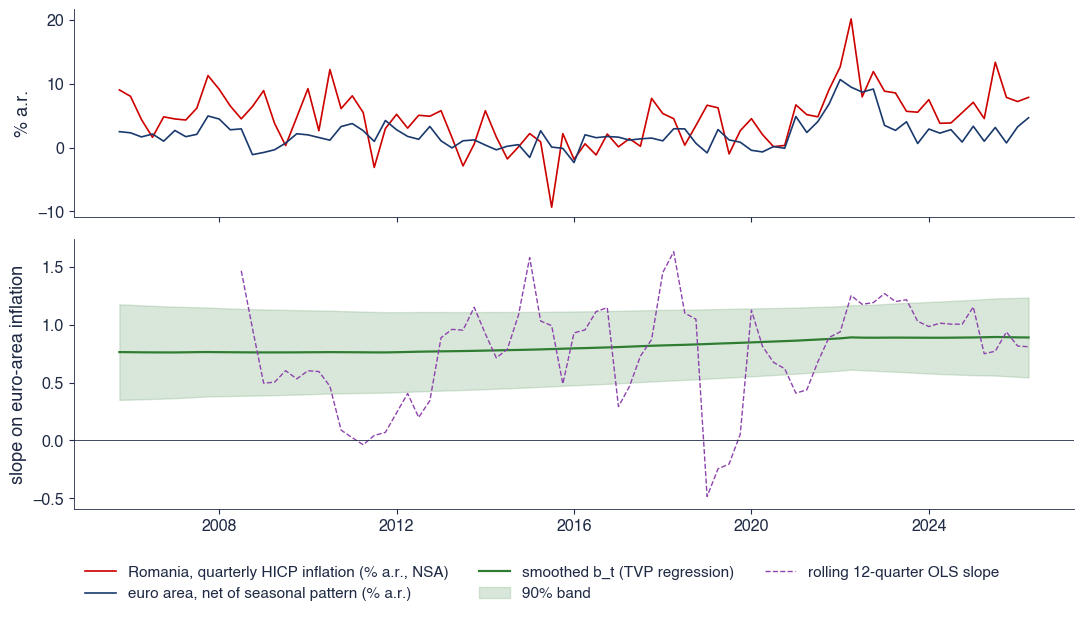

{'par': [0.33171169967402525, 0.0010778850938915818, 7.2143111304649254], 'LR': 0.06594992483019269, 'pboot': 0.35, 'b_at': {'2008-07-01': [0.7612714672914759, 0.22840632578352071], '2015-07-01': [0.7893809203433031, 0.19584676868071216], '2019-10-01': [0.8433316024550759, 0.17920136651822474], '2022-10-01': [0.8873440392663869, 0.17312104327690744]}}


In [13]:
def quarterly_inflation(geo):
    """Quarterly HICP inflation of a country: quarterly averages of the monthly index (Eurostat prc_hicp_minr),
    400 x log difference (% a.r.), complete quarters only, not seasonally adjusted."""
    p = hicp_index(geo)
    q = p.resample('QS').mean()
    q = q[p.resample('QS').count() == 3]
    return (400 * np.log(q).diff()).dropna()


def seasonal_dummies(index):
    """Quarterly dummies in sum-to-zero form (Q1-Q4, Q2-Q4, Q3-Q4)."""
    qq = np.asarray(index.quarter)
    return np.column_stack([(qq == k).astype(float) - (qq == 4).astype(float) for k in (1, 2, 3)])


def tvp_data(geo='RO', start=TVP['start']):
    """y: quarterly HICP inflation of a country; x: euro-area quarterly HICP inflation net of its deterministic
    seasonal pattern (regression on sum-to-zero quarterly dummies over the sample)."""
    d = pd.concat([quarterly_inflation(geo), quarterly_inflation('EA')], axis=1, keys=['y', 'x']).dropna()
    d = d.loc[start:].copy()
    D = seasonal_dummies(d.index)
    d['x'] = d['x'] - D @ np.linalg.lstsq(D, d['x'].values - d['x'].mean(), rcond=None)[0]
    return d


def tvp_model(d, s2c, s2b, s2e):
    """y_t = c_t + b_t x_t + D_t gamma + eps_t; c_t and b_t random walks; the three seasonal coefficients gamma are
    constant states. All five states are exact diffuse (d = 5)."""
    D = seasonal_dummies(d.index)
    Z = np.column_stack([np.ones(len(d)), d['x'].values, D])
    return ssm(Z, np.eye(5), np.eye(5), np.diag([s2c, s2b, 0, 0, 0]), s2e, Pinf=np.eye(5))


def fit_tvp(d, restricted=False):
    """Exact diffuse ML of the TVP regression (numpy): log-variances; restricted = constant slope (s2b = 0)."""
    y = d['y'].values

    def unpack(th):
        return (np.exp(th[0]), 0.0, np.exp(th[1])) if restricted else tuple(np.exp(th))
    f = lambda th: -kalman_filter(y, tvp_model(d, *unpack(th)))['loglik']   # noqa: E731
    starts = [[-3.0, -5.0, 1.0], [-1.0, -2.0, 1.0], [-6.0, -1.0, 1.5]]
    if restricted:
        starts = [[s_[0], s_[2]] for s_ in starts]
    best = min((optimize.minimize(f, s_, method='Nelder-Mead', options=dict(maxiter=4000, xatol=1e-7, fatol=1e-9))
                for s_ in starts), key=lambda r: r.fun)
    return dict(par=[float(x) for x in unpack(best.x)], loglik=float(-best.fun))


def tvp_statsmodels(d, restricted=False):
    """The same model in statsmodels (MLEModel, exact diffuse initialisation): fast refits in the bootstrap."""
    import statsmodels.api as sm
    D = seasonal_dummies(d.index)
    Z = np.column_stack([np.ones(len(d)), d['x'].values, D]).T[None, :, :]

    class TVP(sm.tsa.statespace.MLEModel):
        def __init__(self, endog):
            super().__init__(endog, k_states=5, k_posdef=5, initialization='diffuse')
            self['design'] = Z
            self['transition'] = np.eye(5)
            self['selection'] = np.eye(5)

        @property
        def start_params(self):
            return np.array([0.1, 1.0]) if restricted else np.array([0.1, 0.001, 1.0])

        def transform_params(self, u):
            return u ** 2

        def untransform_params(self, p):
            return np.sqrt(p)

        def update(self, params, **kw):
            params = super().update(params, **kw)
            sc, sb, se = (params[0], 0.0, params[1]) if restricted else params
            self['state_cov'] = np.diag([sc, sb, 0, 0, 0])
            self['obs_cov'] = np.array([[se]])
    m = TVP(d['y'].values)
    best = None
    for s0 in ([0.3, 7.0], [0.05, 3.0]) if restricted else ([0.3, 0.001, 7.0], [0.05, 0.01, 3.0], [1.0, 0.0001, 5.0]):
        r = m.fit(s0, disp=False, maxiter=2000)
        if best is None or r.llf > best.llf:
            best = r
    return best


def fig_tvp(save_it=True, B=199):
    """TVP regression of Romanian on euro-area quarterly HICP inflation since 2005Q3: smoothed b_t with 90% bands
    against a rolling 12-quarter OLS slope; numpy against statsmodels; LR test of a constant slope with a
    parametric bootstrap p-value (the null puts the variance on the boundary of the parameter space)."""
    d = tvp_data()
    t0 = time.time()
    fu = fit_tvp(d)
    fr = fit_tvp(d, restricted=True)
    t_np = time.time() - t0
    smu = tvp_statsmodels(d)
    mod = tvp_model(d, *fu['par'])
    sm_ = kalman_smoother(d['y'].values, mod)
    b, sb = sm_['alpha'][:, 1], np.sqrt(sm_['V'][:, 1, 1])
    LR = max(2 * (fu['loglik'] - fr['loglik']), 0.0)
    rng = np.random.default_rng(SEED)
    m0 = tvp_model(d, *fr['par'])
    a0 = kalman_smoother(d['y'].values, m0)['alpha'][0]
    LRb = []
    for _ in range(B):
        m0b = dict(m0)
        m0b['a1'], m0b['Pinf'] = a0.copy(), np.zeros((5, 5))
        _, yb = simulate_ssm(m0b, len(d), rng)
        db = d.copy()
        db['y'] = yb
        try:
            LRb.append(max(2 * (tvp_statsmodels(db).llf - tvp_statsmodels(db, True).llf), 0.0))
        except Exception:
            continue
    LRb = np.array(LRb)
    pboot = float((1 + np.sum(LRb >= LR - 1e-9)) / (1 + len(LRb)))
    pmix = float(0.5 * (1 - stats.chi2.cdf(LR, 1))) if LR > 0 else 1.0
    D = seasonal_dummies(d.index)
    roll = np.full(len(d), np.nan)
    for i in range(11, len(d)):
        X = np.column_stack([np.ones(12), d['x'].values[i - 11:i + 1], D[i - 11:i + 1]])
        roll[i] = np.linalg.lstsq(X, d['y'].values[i - 11:i + 1], rcond=None)[0][1]
    z = stats.norm.ppf(0.95)
    fig, ax = plt.subplots(2, 1, figsize=(11, 5.6), sharex=True, gridspec_kw=dict(height_ratios=[1, 1.3]))
    ax[0].plot(d.index, d['y'], color=st.IDAred, lw=1.2, label='Romania, quarterly HICP inflation (% a.r., NSA)')
    ax[0].plot(d.index, d['x'], color=st.MainBlue, lw=1.2, label='euro area, net of seasonal pattern (% a.r.)')
    ax[0].set_ylabel('% a.r.')
    ax[1].plot(d.index, b, color=st.Forest, lw=1.6, label='smoothed b_t (TVP regression)')
    ax[1].fill_between(d.index, b - z * sb, b + z * sb, color=st.Forest, alpha=0.18, label='90% band')
    ax[1].plot(d.index, roll, color=st.Purple, lw=1.0, ls='--', label='rolling 12-quarter OLS slope')
    ax[1].axhline(0, color=st.DarkText, lw=0.6)
    ax[1].set_ylabel('slope on euro-area inflation')
    st.fig_legend_bottom(fig, ncol=3, y=-0.0)
    fig.tight_layout()
    save('ats_ch6_tvp', save_it)
    idx = {k: int(np.argmin(np.abs(d.index - pd.Timestamp(k)))) for k in ('2008-07-01', '2015-07-01', '2019-10-01',
                                                                        '2022-10-01')}
    return dict(T=len(d), first=str(d.index[0].date()), last=str(d.index[-1].date()), par=fu['par'], ll=fu['loglik'],
                ll_r=fr['loglik'], par_r=fr['par'], sm_ll=float(smu.llf), sm_par=[float(x) for x in smu.params],
                LR=LR, pboot=pboot, pmix=pmix, B=int(len(LRb)), lr_q95=float(np.quantile(LRb, 0.95)),
                zero_share=float(np.mean(LRb < 1e-6)),
                b_at={k: [float(b[i]), float(sb[i])] for k, i in idx.items()}, b_last=[float(b[-1]), float(sb[-1])],
                b_min=float(b.min()), b_max=float(b.max()), t_np=t_np, seas=sm_['alpha'][-1, 2:].tolist())


r = fig_tvp(save_it=False, B=39)
print({k: r[k] for k in ('par', 'LR', 'pboot', 'b_at')})

## 9. A dynamic factor model at the ragged edge

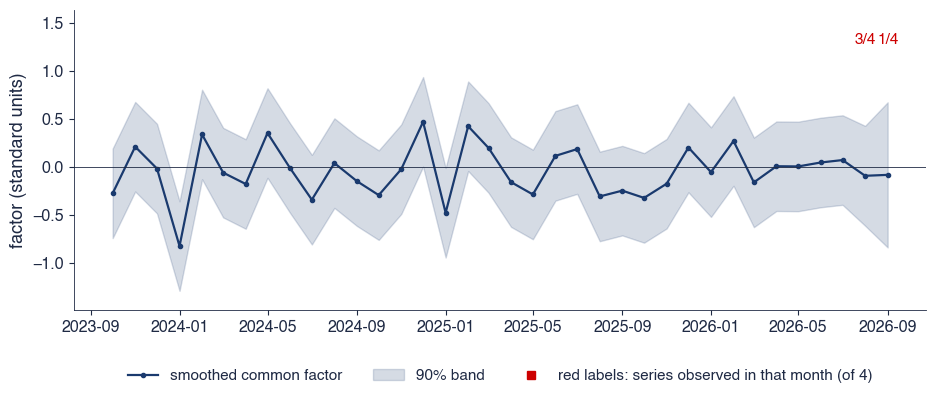

{'lam': [0.8983653183243115, 0.8853970334128034, 0.6811613624568171, 0.8377297460217414], 'a': 0.1156751831947976, 's2e': [0.1835098004961719, 0.2091899277621583, 0.5303015463982795, 0.28774756022234343], 'first': '1990-01-01', 'last': '2026-09-01', 'last_full': '2026-07-01', 'sd_full': 0.28318065322820984, 'sd_last': 0.45901936452279485, 'avail': {'INDPRO': '2026-08-01', 'PAYEMS': '2026-09-01', 'W875RX1': '2026-08-01', 'CMRMTSPL': '2026-07-01'}, 'T': 441, 'f_last': -0.08329578223827626}


In [14]:
def dfm_data(start='1990-01-01'):
    """Monthly growth rates (100 x log difference) of the four US coincident indicators of Stock and Watson (FRED)."""
    x = read_fred(list(DFM_SERIES))
    g = 100 * np.log(x).diff()
    return g.loc[start:].dropna(how='all')


def dfm_two_step(X):
    """Doz, Giannone and Reichlin (2011) two-step estimator with one factor: principal component on the balanced
    panel, AR(1) for the factor, diagonal idiosyncratic variances; then the Kalman smoother on the full (ragged)
    panel with the univariate treatment of the observation vector (Koopman and Durbin 2000)."""
    mu, sd = X.mean(), X.std()
    Zs = ((X - mu) / sd)
    bal = Zs.dropna()
    w, V = np.linalg.eigh(np.cov(bal.T.values))
    lam = V[:, -1] * np.sign(V[:, -1].sum())
    f = bal.values @ lam
    a = float(np.linalg.lstsq(f[:-1, None], f[1:], rcond=None)[0][0])
    s2u = float(np.var(f[1:] - a * f[:-1]))
    lam = lam * np.sqrt(s2u)                     # normalise the factor innovation variance to 1
    f = f / np.sqrt(s2u)
    s2e = np.var(bal.values - np.outer(f, lam), axis=0)
    Y = Zs.values
    n = len(Y)
    at, Pt, ap, Pp = np.zeros(n), np.zeros(n), np.zeros(n), np.zeros(n)
    fa, fP = 0.0, 1 / (1 - a ** 2)
    for t in range(n):
        ap[t], Pp[t] = fa, fP
        for i in range(Y.shape[1]):                # univariate treatment: one series at a time
            if np.isnan(Y[t, i]):
                continue
            F = lam[i] ** 2 * fP + s2e[i]
            k = fP * lam[i] / F
            fa = fa + k * (Y[t, i] - lam[i] * fa)
            fP = fP - k * lam[i] * fP
        at[t], Pt[t] = fa, fP
        fa, fP = a * fa, a ** 2 * fP + 1.0
    fs, Ps = at.copy(), Pt.copy()
    for t in range(n - 2, -1, -1):                 # Rauch-Tung-Striebel smoother for the scalar factor
        G = Pt[t] * a / Pp[t + 1]
        fs[t] = at[t] + G * (fs[t + 1] - ap[t + 1])
        Ps[t] = Pt[t] + G ** 2 * (Ps[t + 1] - Pp[t + 1])
    return dict(lam=lam, a=a, s2e=s2e, f=fs, Pf=Ps, att=at, Ptt=Pt, index=X.index, missing=np.isnan(Y))


def fig_dfm(save_it=True):
    """One-factor DFM of the US coincident indicators with the ragged edge at the end of the sample."""
    X = dfm_data()
    r = dfm_two_step(X)
    k = 36
    idx = r['index'][-k:]
    z = stats.norm.ppf(0.95)
    fig, ax = plt.subplots(figsize=(11, 3.9))
    f, s = r['f'][-k:], np.sqrt(r['Pf'][-k:])
    ax.plot(idx, f, color=st.MainBlue, lw=1.6, marker='o', ms=3, label='smoothed common factor')
    ax.fill_between(idx, f - z * s, f + z * s, color=st.MainBlue, alpha=0.18, label='90% band')
    miss = r['missing'][-k:].sum(1)
    top = (f + z * s).max() + 0.35
    for t_, m_ in zip(idx, miss):
        if m_ > 0:
            ax.annotate(f'{4 - m_}/4', (t_, top), ha='center', fontsize=11, color=st.IDAred)
    ax.set_ylim((f - z * s).min() - 0.2, top + 0.35)
    ax.plot([], [], ls='none', marker='s', color=st.IDAred, label='red labels: series observed in that month (of 4)')
    ax.axhline(0, color=st.DarkText, lw=0.6)
    ax.set_ylabel('factor (standard units)')
    st.legend_outside_bottom(ax, ncol=3, y=-0.15)
    save('ats_ch6_dfm', save_it)
    last_full = int(np.where(r['missing'].sum(1) == 0)[0][-1])
    return dict(lam=r['lam'].tolist(), a=r['a'], s2e=r['s2e'].tolist(), first=str(X.index[0].date()),
                last=str(X.index[-1].date()), last_full=str(X.index[last_full].date()),
                sd_full=float(np.sqrt(r['Pf'][last_full])), sd_last=float(np.sqrt(r['Pf'][-1])),
                avail={c: str(X[c].dropna().index[-1].date()) for c in X}, T=len(X),
                f_last=float(r['f'][-1]))


print(fig_dfm(save_it=False))

## 10. Trend–cycle: Morley, Nelson and Zivot (2003); the Romanian output gap

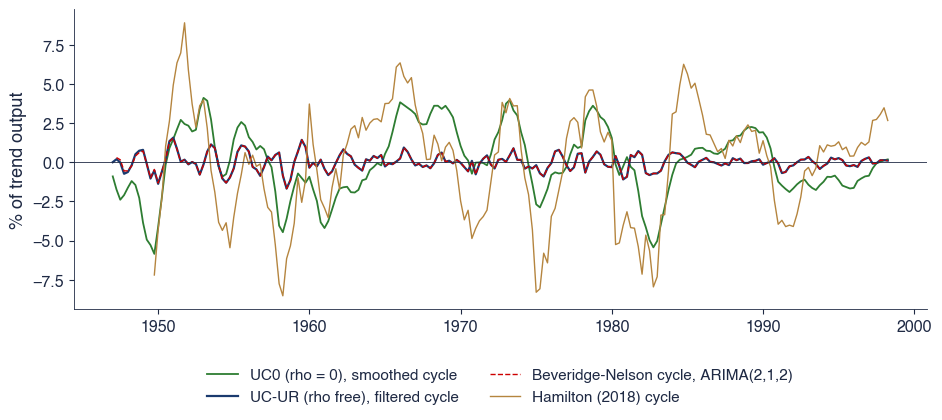

{'par': [0.8593239179984822, 1.3335654541212523, -0.7384723727458318, 1.184929120199332, 0.6689566544102573, -0.926668227827247], 'loglik': -279.35384164179766, 'll_sm': -279.35384164299825, 'th': [0.8593239179984822, 1.022653506213604, -0.9553227301630541, 0.16968295862037633, -0.402036012566941, -1.6342767571923318], 'se_th': [0.08617616575115952, 1.1745808343349006e-10, 5.494380501751734e-10, 0.09947005980072755, 0.137484266565405, 0.7417259791281348]}


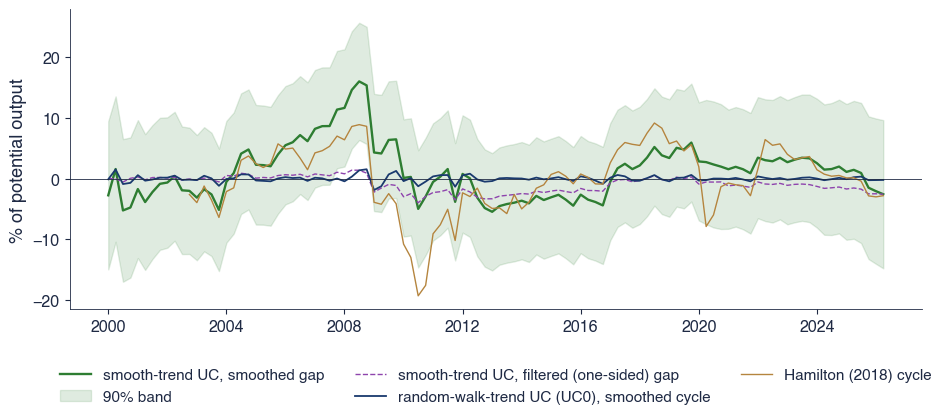

{'par': [0.004591810993411275, 4.9548182263779506, 0.8704656494821196, 0.09066177108674836], 'll_sm': -229.30446046453037, 'loglik': -231.13962697366983}


In [15]:
def fig_mnz(save_it=True):
    """Replication of Morley, Nelson and Zivot (2003) on their sample (US real GDP, 1947Q1-1998Q2, current vintage):
    UC0 against UC-UR, the BN cycle from an ARIMA(2,1,2), and the Hamilton (2018) cycle for comparison."""
    y = gdp_log('US', MNZ['start']).loc[:MNZ['end']]
    r = trend_cycle(y.values, n_starts=16)
    fig, ax = plt.subplots(figsize=(11, 3.9))
    ax.plot(y.index, r['c0_s'], color=st.Forest, lw=1.3, label='UC0 (rho = 0), smoothed cycle')
    ax.plot(y.index, r['c1_f'], color=st.MainBlue, lw=1.6, label='UC-UR (rho free), filtered cycle')
    ax.plot(y.index, r['bn'], color=st.IDAred, lw=1.0, ls='--', label='Beveridge-Nelson cycle, ARIMA(2,1,2)')
    ax.plot(y.index, r['ham'], color=st.Amber, lw=1.0, label='Hamilton (2018) cycle')
    ax.axhline(0, color=st.DarkText, lw=0.6)
    ax.set_ylabel('% of trend output')
    st.legend_outside_bottom(ax, ncol=2, y=-0.15)
    save('ats_ch6_mnz', save_it)
    ok = ~np.isnan(r['bn'])
    return dict(T=len(y), first=str(y.index[0].date()), last=str(y.index[-1].date()), u0=r['u0'], ur=r['ur'],
                LR=r['LR'], p=float(1 - stats.chi2.cdf(r['LR'], 1)), bnp=r['bnp'],
                corr_ur_bn=float(np.corrcoef(r['c1_f'][ok], r['bn'][ok])[0, 1]),
                sd_c0=float(np.std(r['c0_s'])), sd_c1=float(np.std(r['c1_f'])), sd_bn=float(np.nanstd(r['bn'])),
                sd_ham=float(np.nanstd(r['ham'])))


def fig_ro_gap(save_it=True):
    """Romanian output gap, 2000Q1 onward (Eurostat), 2020Q2-Q4 treated as missing: the random-walk-trend UC
    (Clark/MNZ form) puts almost everything in the trend; the smooth-trend UC gives a sizeable gap (smoothed with
    90% band, and filtered); the Hamilton (2018) cycle on the full series."""
    y = ro_gdp_covid_missing()
    u0 = fit_uc(y.values, False, 12)
    ur = fit_uc(y.values, True, 12)
    stt = fit_smooth_trend(y.values)
    s0 = kalman_smoother(y.values, uc_model(*u0['par']))
    s2 = kalman_smoother(y.values, smooth_trend_model(*stt['par']))
    gap_s, gap_sd, gap_f = s2['alpha'][:, 2], np.sqrt(s2['V'][:, 2, 2]), s2['kf']['att'][:, 2]
    yf = gdp_log('RO', '2000-01-01')
    ham = hamilton_filter(yf.values)
    z = stats.norm.ppf(0.95)
    fig, ax = plt.subplots(figsize=(11, 3.9))
    ax.plot(y.index, gap_s, color=st.Forest, lw=1.7, label='smooth-trend UC, smoothed gap')
    ax.fill_between(y.index, gap_s - z * gap_sd, gap_s + z * gap_sd, color=st.Forest, alpha=0.15, label='90% band')
    ax.plot(y.index, gap_f, color=st.Purple, lw=1.0, ls='--', label='smooth-trend UC, filtered (one-sided) gap')
    ax.plot(y.index, s0['alpha'][:, 1], color=st.MainBlue, lw=1.3, label='random-walk-trend UC (UC0), smoothed cycle')
    ax.plot(yf.index, ham, color=st.Amber, lw=1.0, label='Hamilton (2018) cycle')
    ax.axhline(0, color=st.DarkText, lw=0.6)
    ax.set_ylabel('% of potential output')
    st.legend_outside_bottom(ax, ncol=3, y=-0.15)
    save('ats_ch6_ro_gap', save_it)
    at = {k: int(np.argmin(np.abs(y.index - pd.Timestamp(k)))) for k in ('2008-07-01', '2010-07-01', '2019-10-01')}
    ok = ~np.isnan(ham) & ~np.isnan(y.values)
    return dict(T=len(y), first=str(y.index[0].date()), last=str(y.index[-1].date()), u0=u0, ur=ur, st=stt,
                LR=float(2 * (ur['loglik'] - u0['loglik'])),
                gap_at={k: [float(gap_s[i]), float(gap_sd[i]), float(gap_f[i])] for k, i in at.items()},
                last_s=float(gap_s[-1]), last_f=float(gap_f[-1]), last_sd=float(gap_sd[-1]),
                last_ham=float(ham[-1]), sd_gap=float(np.nanstd(gap_s)), sd_uc0=float(np.nanstd(s0['alpha'][:, 1])),
                sd_ham=float(np.nanstd(ham)), corr_gap_ham=float(np.corrcoef(gap_s[ok], ham[ok])[0, 1]),
                rev_sd=float(np.nanstd(gap_s - gap_f)))


print(fig_mnz(save_it=False)['ur'])
print(fig_ro_gap(save_it=False)['st'])

## 11. UC-SV trend inflation (Stock and Watson 2007)

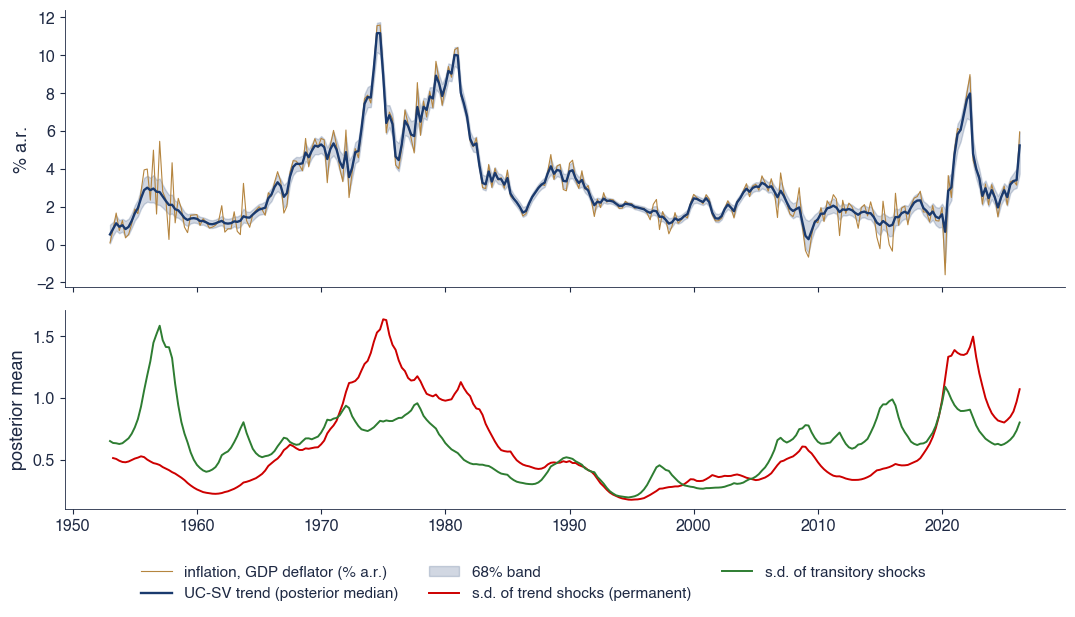

[3.742820988076928, 5.235163212150412, 5.9536548125140225]


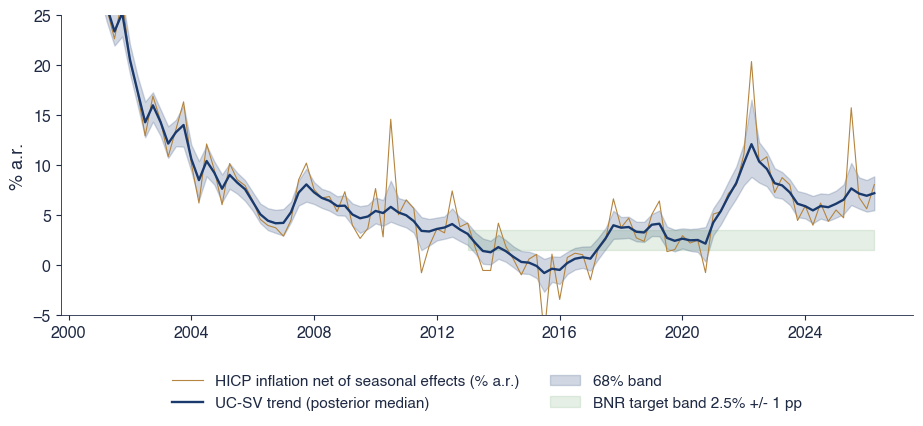

[5.511605238176801, 7.215968278327705, 8.896590497948903]


In [16]:
def ucsv_gibbs(pi, gamma=UCSV['gamma'], draws=20000, burn=5000, seasonal=None, rng=None, offset=1e-3):
    """UC-SV of Stock and Watson (2007): pi_t = tau_t + exp(h1_t/2) eta_t, tau_t = tau_{t-1} + exp(h2_t/2) eps_t,
    h_jt = h_j,t-1 + nu_jt, var(nu) = gamma (fixed). Gibbs: tau by the precision sampler; the log-volatilities by the
    KSC mixture and the precision sampler; optional quarterly seasonal dummies (sum-to-zero) for a non-adjusted series."""
    rng = rng or np.random.default_rng(SEED)
    pi = np.asarray(pi, float)
    n = len(pi)
    D = None
    if seasonal is not None:
        qq = np.asarray(seasonal)
        D = np.column_stack([(qq == k).astype(float) - (qq == 4).astype(float) for k in (1, 2, 3)])
    g = np.zeros(3)
    v0 = np.log(np.var(pi))
    h1, h2 = np.full(n, v0), np.full(n - 1, v0 - 2)
    tau = pi.copy()
    keep = dict(tau=np.zeros((draws, n)), s1=np.zeros(n), s2=np.zeros(n - 1), g=np.zeros((draws, 3)))
    for it in range(draws + burn):
        ys = pi - (D @ g if D is not None else 0)
        tau = precision_rw(ys, np.exp(h1), np.r_[1.0, np.exp(h2)], ys[:4].mean(), 25.0, rng)
        e1 = ys - tau
        e2 = np.diff(tau)
        for e, which in ((e1, 1), (e2, 2)):
            yst = np.log(e ** 2 + offset)
            h = h1 if which == 1 else h2
            s = draw_s_ksc(yst, h, rng)
            h = precision_rw(yst - (KSC_M[s] - 1.2704), KSC_V[s], gamma, h[0], 10.0, rng)
            if which == 1:
                h1 = h
            else:
                h2 = h
        if D is not None:
            w = np.exp(-h1)
            Vp = np.linalg.inv(D.T @ (D * w[:, None]) + np.eye(3) / 10)
            g = Vp @ (D.T @ (w * (pi - tau))) + np.linalg.cholesky(Vp) @ rng.standard_normal(3)
        if it >= burn:
            k = it - burn
            keep['tau'][k] = tau
            keep['s1'] += np.exp(h1 / 2)
            keep['s2'] += np.exp(h2 / 2)
            keep['g'][k] = g
    keep['s1'] /= draws
    keep['s2'] /= draws
    return keep


def fig_ucsv_us(save_it=True, draws=20000, burn=5000):
    """UC-SV trend of US GDP-deflator inflation, 1953Q1 onward: trend with 68% band; permanent and transitory
    volatilities; the implied IMA(1,1) coefficient theta_t (Stock and Watson 2007, Fig. 4 logic)."""
    pi = us_inflation(UCSV['start_us'])
    k = ucsv_gibbs(pi.values, draws=draws, burn=burn)
    tau = k['tau']
    lo, md, hi = np.quantile(tau, [0.16, 0.5, 0.84], axis=0)
    s1, s2 = k['s1'], np.r_[np.nan, k['s2']]
    q = (s2 / s1) ** 2
    theta = -(1 + q / 2 - np.sqrt(q + q ** 2 / 4))
    fig, ax = plt.subplots(2, 1, figsize=(11, 5.6), sharex=True, gridspec_kw=dict(height_ratios=[1.4, 1]))
    ax[0].plot(pi.index, pi.values, color=st.Amber, lw=0.8, label='inflation, GDP deflator (% a.r.)')
    ax[0].plot(pi.index, md, color=st.MainBlue, lw=1.7, label='UC-SV trend (posterior median)')
    ax[0].fill_between(pi.index, lo, hi, color=st.MainBlue, alpha=0.2, label='68% band')
    ax[0].set_ylabel('% a.r.')
    ax[1].plot(pi.index, s2, color=st.IDAred, lw=1.4, label='s.d. of trend shocks (permanent)')
    ax[1].plot(pi.index, s1, color=st.Forest, lw=1.4, label='s.d. of transitory shocks')
    ax[1].set_ylabel('posterior mean')
    st.fig_legend_bottom(fig, ncol=3, y=-0.0)
    fig.tight_layout()
    save('ats_ch6_ucsv_us', save_it)
    at = {k_: int(np.argmin(np.abs(pi.index - pd.Timestamp(k_)))) for k_ in
          ('1975-01-01', '1980-01-01', '1995-01-01', '2005-01-01', '2019-10-01', '2022-04-01')}
    return dict(T=len(pi), first=str(pi.index[0].date()), last=str(pi.index[-1].date()), draws=draws, burn=burn,
                tau_at={k_: [float(lo[i]), float(md[i]), float(hi[i])] for k_, i in at.items()},
                s1_at={k_: float(s1[i]) for k_, i in at.items()}, s2_at={k_: float(s2[i]) for k_, i in at.items()},
                theta_at={k_: float(theta[i]) for k_, i in at.items()},
                tau_last=[float(lo[-1]), float(md[-1]), float(hi[-1])], pi_last=float(pi.values[-1]),
                pi_4q=float(pi.values[-4:].mean()))


def fig_ucsv_ro(save_it=True, draws=20000, burn=5000):
    """UC-SV trend of Romanian HICP inflation, quarterly 2001Q1 onward, with quarterly seasonal dummies; the BNR
    target band (2.5% +/- 1 pp since 2013)."""
    pi = ro_quarterly_inflation()
    k = ucsv_gibbs(pi.values, draws=draws, burn=burn, seasonal=pi.index.quarter)
    tau = k['tau']
    lo, md, hi = np.quantile(tau, [0.16, 0.5, 0.84], axis=0)
    fig, ax = plt.subplots(figsize=(11, 3.9))
    sa = pi.values - (np.column_stack([(pi.index.quarter == j).astype(float) - (pi.index.quarter == 4).astype(float)
                                       for j in (1, 2, 3)]) @ k['g'].mean(0))
    ax.plot(pi.index, sa, color=st.Amber, lw=0.8, label='HICP inflation net of seasonal effects (% a.r.)')
    ax.plot(pi.index, md, color=st.MainBlue, lw=1.7, label='UC-SV trend (posterior median)')
    ax.fill_between(pi.index, lo, hi, color=st.MainBlue, alpha=0.2, label='68% band')
    tgt = pi.index >= pd.Timestamp('2013-01-01')
    ax.fill_between(pi.index[tgt], 1.5, 3.5, color=st.Forest, alpha=0.12, label='BNR target band 2.5% +/- 1 pp')
    ax.set_ylabel('% a.r.')
    ax.set_ylim(-5, max(25, np.nanmax(sa[pi.index >= '2003-01-01']) + 1))
    st.legend_outside_bottom(ax, ncol=2, y=-0.15)
    save('ats_ch6_ucsv_ro', save_it)
    post_in = float(np.mean((tau[:, -1] >= 1.5) & (tau[:, -1] <= 3.5)))
    at = {k_: int(np.argmin(np.abs(pi.index - pd.Timestamp(k_)))) for k_ in
          ('2005-07-01', '2015-07-01', '2019-10-01', '2023-01-01')}
    return dict(T=len(pi), first=str(pi.index[0].date()), last=str(pi.index[-1].date()), draws=draws,
                tau_at={k_: [float(lo[i]), float(md[i]), float(hi[i])] for k_, i in at.items()},
                tau_last=[float(lo[-1]), float(md[-1]), float(hi[-1])], post_in_band=post_in,
                seas=k['g'].mean(0).tolist(), s1_last=float(k['s1'][-1]), s2_last=float(k['s2'][-1]))


print(fig_ucsv_us(save_it=False, draws=3000, burn=1000)['tau_last'])
print(fig_ucsv_ro(save_it=False, draws=3000, burn=1000)['tau_last'])

## 12. AI mini-case: the fixed parameter gamma

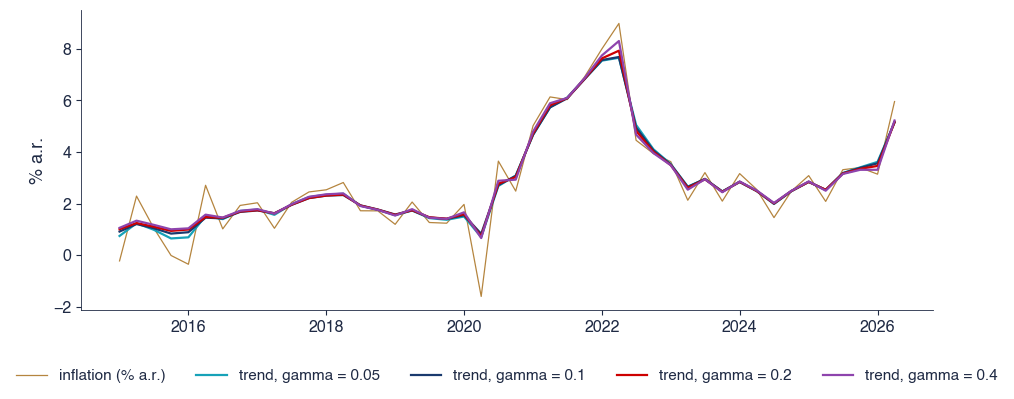

{'0.05': {'peak': 7.649998085846954, 'last': 5.143811851510806, 'peak_lo': 6.559043952734295, 'peak_hi': 8.607026136010676}, '0.1': {'peak': 7.678742397185255, 'last': 5.1538359350174785, 'peak_lo': 6.385413021166733, 'peak_hi': 8.724911303430389}, '0.2': {'peak': 7.9234648556004075, 'last': 5.154704157221041, 'peak_lo': 6.546530000968233, 'peak_hi': 8.871670249625636}, '0.4': {'peak': 8.298456563041523, 'last': 5.218810815068567, 'peak_lo': 6.675204845019612, 'peak_hi': 8.985198557565532}, 'peak_min': 7.649998085846954, 'peak_max': 8.298456563041523, 'pi_peak': 8.979102810170758, 'peak_date': '2022-04-01'}


In [17]:
def fig_ai_case(save_it=True, gammas=(0.05, 0.1, 0.2, 0.4), draws=20000, burn=5000):
    """How much does the UC-SV trend of US inflation (2015 onward) depend on gamma, the variance of the log-volatility
    shocks that Stock and Watson (2007) fix at 0.2? Trend at the 2022 peak and at the end of the sample."""
    pi = us_inflation(UCSV['start_us'])
    k = pi.index >= pd.Timestamp('2015-01-01')
    fig, ax = plt.subplots(figsize=(11, 3.9))
    ax.plot(pi.index[k], pi.values[k], color=st.Amber, lw=0.9, label='inflation (% a.r.)')
    cols = [st.Teal, st.MainBlue, st.IDAred, st.Purple]
    out = {}
    i22 = int(np.argmin(np.abs(pi.index - pd.Timestamp('2022-04-01'))))
    for gm, c in zip(gammas, cols):
        kk = ucsv_gibbs(pi.values, gamma=gm, draws=draws, burn=burn, rng=np.random.default_rng(SEED))
        md = np.median(kk['tau'], 0)
        ax.plot(pi.index[k], md[k], color=c, lw=1.6, label=f'trend, gamma = {gm}')
        out[str(gm)] = dict(peak=float(md[i22]), last=float(md[-1]),
                            peak_lo=float(np.quantile(kk['tau'][:, i22], 0.16)),
                            peak_hi=float(np.quantile(kk['tau'][:, i22], 0.84)))
    ax.set_ylabel('% a.r.')
    st.legend_outside_bottom(ax, ncol=5, y=-0.15)
    save('ats_ch6_ai_case', save_it)
    pk = [v['peak'] for v in out.values()]
    return dict(out, peak_min=float(min(pk)), peak_max=float(max(pk)), pi_peak=float(pi.values[i22]),
                peak_date=str(pi.index[i22].date()))


print(fig_ai_case(save_it=False, draws=2000, burn=500))

## Exercises

1. Replace the KSC offset by 0.001 (unscaled) and re-estimate SV for EUR/RON: what changes?
2. Add Student-t errors to the bootstrap particle filter of the SV model and compare the log-likelihood.
3. Estimate the MNZ model on the sample extended to the latest quarter: is the correlation still close to -1?